# Mollweide: a world from a function

The challenge is a world map that keeps relative areas within an ellipse twice as wide as it is tall. Shapes and distances change. Karl Brandan Mollweide introduced it in 1805. [Projection reference](https://proj.org/en/stable/operations/projections/moll.html).

Before running: What must happen to the equator, the poles, and the outline? Make a prediction, then compare it with the map.

Run cells from top to bottom. This notebook includes Natural Earth land geometry and uses GeoPandas, NumPy and Matplotlib. nteract reads the declared dependencies; other notebook environments can use the setup cell. First-time installation requires internet access.

## Worked solution

This file intentionally includes the answer. Bisection solves the auxiliary-angle equation in a fixed bracket. At the poles we explicitly return a single point. Run in order, then compare with your own approach.

In [1]:
import importlib.util
import sys

missing = [name for name in ("numpy", "matplotlib", "geopandas")
           if importlib.util.find_spec(name) is None]
if missing:
    if sys.platform == "emscripten":
        import micropip
        await micropip.install(missing)
    else:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
print("NumPy, GeoPandas and Matplotlib are ready.")

NumPy, GeoPandas and Matplotlib are ready.


## The projection

Change the function below, then rerun the map. Inputs are longitude and latitude in radians; outputs are planar coordinates for a unit-radius sphere.

In [2]:
import numpy as np

central_meridian = 0  # degrees; east positive

def project(lon, lat):
    lon = (lon - np.radians(central_meridian) + np.pi) % (2 * np.pi) - np.pi
    # Solve 2*theta + sin(2*theta) = pi*sin(latitude).
    # Bisection is slower than Newton's method, but stays inside the bracket
    # and avoids division by a derivative that vanishes at the poles.
    low = np.full_like(lat, -np.pi / 2, dtype=float)
    high = np.full_like(lat, np.pi / 2, dtype=float)
    target = np.pi * np.sin(lat)
    for _ in range(50):
        theta = (low + high) / 2
        below = 2 * theta + np.sin(2 * theta) < target
        low = np.where(below, theta, low)
        high = np.where(below, high, theta)
    theta = (low + high) / 2
    # At a pole all longitudes meet at one point.
    pole = np.abs(lat) >= np.pi / 2 - 1e-12
    x = 2 * np.sqrt(2) / np.pi * lon * np.cos(theta)
    y = np.sqrt(2) * np.sin(theta)
    return np.where(pole, 0, x), np.where(pole, np.sign(lat) * np.sqrt(2), y)


## Real geography

Natural Earth 1:110m land polygons, embedded in this file (public domain). GeoPandas holds the geographic features in longitude/latitude coordinates. The custom Python function projects their coastlines directly; it is not a standard GeoPandas CRS conversion.

[About Natural Earth](https://www.naturalearthdata.com/about/terms-of-use/)

In [3]:
import json
land = gpd.GeoDataFrame.from_features(json.loads("{\"type\":\"FeatureCollection\",\"name\":\"ne_110m_land\",\"crs\":{\"type\":\"name\",\"properties\":{\"name\":\"urn:ogc:def:crs:OGC:1.3:CRS84\"}},\"features\":[{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-66.290031,-81.000327,-59.572095,-79.628679],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-59.572095,-80.040179],[-59.865849,-80.549657],[-60.159656,-81.000327],[-62.255393,-80.863178],[-64.488125,-80.921934],[-65.741666,-80.588827],[-65.741666,-80.549657],[-66.290031,-80.255773],[-64.037688,-80.294944],[-61.883246,-80.39287],[-61.138976,-79.981371],[-60.610119,-79.628679],[-59.572095,-80.040179]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-163.712896,-79.634209,-159.208184,-78.223338],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-159.208184,-79.497059],[-161.127601,-79.634209],[-162.439847,-79.281465],[-163.027408,-78.928774],[-163.066604,-78.869966],[-163.712896,-78.595667],[-163.712896,-78.595667],[-163.105801,-78.223338],[-161.245113,-78.380176],[-160.246208,-78.693645],[-159.482405,-79.046338],[-159.208184,-79.497059]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":0},\"bbox\":[-54.164259,-81.025442,-43.333267,-77.831476],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-45.154758,-78.04707],[-43.920828,-78.478103],[-43.48995,-79.08556],[-43.372438,-79.516645],[-43.333267,-80.026123],[-44.880537,-80.339644],[-46.506174,-80.594357],[-48.386421,-80.829485],[-50.482107,-81.025442],[-52.851988,-80.966685],[-54.164259,-80.633528],[-53.987991,-80.222028],[-51.853134,-79.94773],[-50.991326,-79.614623],[-50.364595,-79.183487],[-49.914131,-78.811209],[-49.306959,-78.458569],[-48.660616,-78.047018],[-48.660616,-78.047019],[-48.151396,-78.04707],[-46.662857,-77.831476],[-45.154758,-78.04707]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-122.621735,-74.08881,-118.724143,-73.324619],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-121.211511,-73.50099],[-119.918851,-73.657725],[-118.724143,-73.481353],[-119.292119,-73.834097],[-120.232217,-74.08881],[-121.62283,-74.010468],[-122.621735,-73.657778],[-122.621735,-73.657777],[-122.406245,-73.324619],[-121.211511,-73.50099]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-127.28313,-73.873268,-124.031882,-73.246226],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-125.559566,-73.481353],[-124.031882,-73.873268],[-124.619469,-73.834097],[-125.912181,-73.736118],[-127.28313,-73.461769],[-127.28313,-73.461768],[-126.558472,-73.246226],[-125.559566,-73.481353]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-102.330725,-72.521205,-96.20035,-71.717792],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-98.98155,-71.933334],[-97.884743,-72.070535],[-96.787937,-71.952971],[-96.20035,-72.521205],[-96.983765,-72.442864],[-98.198083,-72.482035],[-99.432013,-72.442864],[-100.783455,-72.50162],[-101.801868,-72.305663],[-102.330725,-71.894164],[-102.330725,-71.894164],[-101.703967,-71.717792],[-100.430919,-71.854993],[-98.98155,-71.933334]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-75.012625,-72.503842,-68.333834,-68.87874],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-68.451346,-70.955823],[-68.333834,-71.406493],[-68.510128,-71.798407],[-68.784297,-72.170736],[-69.959471,-72.307885],[-71.075889,-72.503842],[-72.388134,-72.484257],[-71.8985,-72.092343],[-73.073622,-72.229492],[-74.19004,-72.366693],[-74.953895,-72.072757],[-75.012625,-71.661258],[-73.915819,-71.269345],[-73.915819,-71.269344],[-73.230331,-71.15178],[-72.074717,-71.190951],[-71.780962,-70.681473],[-71.72218,-70.309196],[-71.741791,-69.505782],[-71.173815,-69.035475],[-70.253252,-68.87874],[-69.724447,-69.251017],[-69.489422,-69.623346],[-69.058518,-70.074016],[-68.725541,-70.505153],[-68.451346,-70.955823]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-180,-90,180,-63.27066],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-58.614143,-64.152467],[-59.045073,-64.36801],[-59.789342,-64.211223],[-60.611928,-64.309202],[-61.297416,-64.54433],[-62.0221,-64.799094],[-62.51176,-65.09303],[-62.648858,-65.484942],[-62.590128,-65.857219],[-62.120079,-66.190326],[-62.805567,-66.425505],[-63.74569,-66.503847],[-64.294106,-66.837004],[-64.881693,-67.150474],[-65.508425,-67.58161],[-65.665082,-67.953887],[-65.312545,-68.365335],[-64.783715,-68.678908],[-63.961103,-68.913984],[-63.1973,-69.227556],[-62.785955,-69.619419],[-62.570516,-69.991747],[-62.276736,-70.383661],[-61.806661,-70.716768],[-61.512906,-71.089045],[-61.375809,-72.010074],[-61.081977,-72.382351],[-61.003661,-72.774265],[-60.690269,-73.166179],[-60.827367,-73.695242],[-61.375809,-74.106742],[-61.96337,-74.439848],[-63.295201,-74.576997],[-63.74569,-74.92974],[-64.352836,-75.262847],[-65.860987,-75.635124],[-67.192818,-75.79191],[-68.446282,-76.007452],[-69.797724,-76.222995],[-70.600724,-76.634494],[-72.206776,-76.673665],[-73.969536,-76.634494],[-75.555977,-76.712887],[-77.24037,-76.712887],[-76.926979,-77.104802],[-75.399294,-77.28107],[-74.282876,-77.55542],[-73.656119,-77.908112],[-74.772536,-78.221633],[-76.4961,-78.123654],[-77.925858,-78.378419],[-77.984666,-78.789918],[-78.023785,-79.181833],[-76.848637,-79.514939],[-76.633224,-79.887216],[-75.360097,-80.259545],[-73.244852,-80.416331],[-71.442946,-80.69063],[-70.013163,-81.004151],[-68.191646,-81.317672],[-65.704279,-81.474458],[-63.25603,-81.748757],[-61.552026,-82.042692],[-59.691416,-82.37585],[-58.712121,-82.846106],[-58.222487,-83.218434],[-57.008117,-82.865691],[-55.362894,-82.571755],[-53.619771,-82.258235],[-51.543644,-82.003521],[-49.76135,-81.729171],[-47.273931,-81.709586],[-44.825708,-81.846735],[-42.808363,-82.081915],[-42.16202,-81.65083],[-40.771433,-81.356894],[-38.244818,-81.337309],[-36.26667,-81.121715],[-34.386397,-80.906172],[-32.310296,-80.769023],[-30.097098,-80.592651],[-28.549802,-80.337938],[-29.254901,-79.985195],[-29.685805,-79.632503],[-29.685805,-79.260226],[-31.624808,-79.299397],[-33.681324,-79.456132],[-35.639912,-79.456132],[-35.914107,-79.083855],[-35.77701,-78.339248],[-35.326546,-78.123654],[-33.896763,-77.888526],[-32.212369,-77.65345],[-30.998051,-77.359515],[-29.783732,-77.065579],[-28.882779,-76.673665],[-27.511752,-76.497345],[-26.160336,-76.360144],[-25.474822,-76.281803],[-23.927552,-76.24258],[-22.458598,-76.105431],[-21.224694,-75.909474],[-20.010375,-75.674346],[-18.913543,-75.439218],[-17.522982,-75.125698],[-16.641589,-74.79254],[-15.701491,-74.498604],[-15.40771,-74.106742],[-16.46532,-73.871614],[-16.112784,-73.460114],[-15.446855,-73.146542],[-14.408805,-72.950585],[-13.311973,-72.715457],[-12.293508,-72.401936],[-11.510067,-72.010074],[-11.020433,-71.539767],[-10.295774,-71.265416],[-9.101015,-71.324224],[-8.611381,-71.65733],[-7.416622,-71.696501],[-7.377451,-71.324224],[-6.868232,-70.93231],[-5.790985,-71.030289],[-5.536375,-71.402617],[-4.341667,-71.461373],[-3.048981,-71.285053],[-1.795492,-71.167438],[-0.659489,-71.226246],[-0.228637,-71.637745],[0.868195,-71.304639],[1.886686,-71.128267],[3.022638,-70.991118],[4.139055,-70.853917],[5.157546,-70.618789],[6.273912,-70.462055],[7.13572,-70.246512],[7.742866,-69.893769],[8.48711,-70.148534],[9.525135,-70.011333],[10.249845,-70.48164],[10.817821,-70.834332],[11.953824,-70.638375],[12.404287,-70.246512],[13.422778,-69.972162],[14.734998,-70.030918],[15.126757,-70.403247],[15.949342,-70.030918],[17.026589,-69.913354],[18.201711,-69.874183],[19.259373,-69.893769],[20.375739,-70.011333],[21.452985,-70.07014],[21.923034,-70.403247],[22.569403,-70.697182],[23.666184,-70.520811],[24.841357,-70.48164],[25.977309,-70.48164],[27.093726,-70.462055],[28.09258,-70.324854],[29.150242,-70.20729],[30.031583,-69.93294],[30.971733,-69.75662],[31.990172,-69.658641],[32.754053,-69.384291],[33.302443,-68.835642],[33.870419,-68.502588],[34.908495,-68.659271],[35.300202,-69.012014],[36.16201,-69.247142],[37.200035,-69.168748],[37.905108,-69.52144],[38.649404,-69.776205],[39.667894,-69.541077],[40.020431,-69.109941],[40.921358,-68.933621],[41.959434,-68.600514],[42.938702,-68.463313],[44.113876,-68.267408],[44.897291,-68.051866],[45.719928,-67.816738],[46.503343,-67.601196],[47.44344,-67.718759],[48.344419,-67.366068],[48.990736,-67.091718],[49.930885,-67.111303],[50.753471,-66.876175],[50.949325,-66.523484],[51.791547,-66.249133],[52.614133,-66.053176],[53.613038,-65.89639],[54.53355,-65.818049],[55.414943,-65.876805],[56.355041,-65.974783],[57.158093,-66.249133],[57.255968,-66.680218],[58.137361,-67.013324],[58.744508,-67.287675],[59.939318,-67.405239],[60.605221,-67.679589],[61.427806,-67.953887],[62.387489,-68.012695],[63.19049,-67.816738],[64.052349,-67.405239],[64.992447,-67.620729],[65.971715,-67.738345],[66.911864,-67.855909],[67.891133,-67.934302],[68.890038,-67.934302],[69.712624,-68.972791],[69.673453,-69.227556],[69.555941,-69.678226],[68.596258,-69.93294],[67.81274,-70.305268],[67.949889,-70.697182],[69.066307,-70.677545],[68.929157,-71.069459],[68.419989,-71.441788],[67.949889,-71.853287],[68.71377,-72.166808],[69.869307,-72.264787],[71.024895,-72.088415],[71.573285,-71.696501],[71.906288,-71.324224],[72.454627,-71.010703],[73.08141,-70.716768],[73.33602,-70.364024],[73.864877,-69.874183],[74.491557,-69.776205],[75.62756,-69.737034],[76.626465,-69.619419],[77.644904,-69.462684],[78.134539,-69.07077],[78.428371,-68.698441],[79.113859,-68.326216],[80.093127,-68.071503],[80.93535,-67.875546],[81.483792,-67.542388],[82.051767,-67.366068],[82.776426,-67.209282],[83.775331,-67.30726],[84.676206,-67.209282],[85.655527,-67.091718],[86.752359,-67.150474],[87.477017,-66.876175],[87.986289,-66.209911],[88.358411,-66.484261],[88.828408,-66.954568],[89.67063,-67.150474],[90.630365,-67.228867],[91.5901,-67.111303],[92.608539,-67.189696],[93.548637,-67.209282],[94.17542,-67.111303],[95.017591,-67.170111],[95.781472,-67.385653],[96.682399,-67.248504],[97.759646,-67.248504],[98.68021,-67.111303],[99.718182,-67.248504],[100.384188,-66.915346],[100.893356,-66.58224],[101.578896,-66.30789],[102.832411,-65.563284],[103.478676,-65.700485],[104.242557,-65.974783],[104.90846,-66.327527],[106.181561,-66.934931],[107.160881,-66.954568],[108.081393,-66.954568],[109.15864,-66.837004],[110.235835,-66.699804],[111.058472,-66.425505],[111.74396,-66.13157],[112.860378,-66.092347],[113.604673,-65.876805],[114.388088,-66.072762],[114.897308,-66.386283],[115.602381,-66.699804],[116.699161,-66.660633],[117.384701,-66.915346],[118.57946,-67.170111],[119.832924,-67.268089],[120.871,-67.189696],[121.654415,-66.876175],[122.320369,-66.562654],[123.221296,-66.484261],[124.122274,-66.621462],[125.160247,-66.719389],[126.100396,-66.562654],[127.001427,-66.562654],[127.882768,-66.660633],[128.80328,-66.758611],[129.704259,-66.58224],[130.781454,-66.425505],[131.799945,-66.386283],[132.935896,-66.386283],[133.85646,-66.288304],[134.757387,-66.209963],[135.031582,-65.72007],[135.070753,-65.308571],[135.697485,-65.582869],[135.873805,-66.033591],[136.206705,-66.44509],[136.618049,-66.778197],[137.460271,-66.954568],[138.596223,-66.895761],[139.908442,-66.876175],[140.809421,-66.817367],[142.121692,-66.817367],[143.061842,-66.797782],[144.374061,-66.837004],[145.490427,-66.915346],[146.195552,-67.228867],[145.999699,-67.601196],[146.646067,-67.895131],[147.723263,-68.130259],[148.839629,-68.385024],[150.132314,-68.561292],[151.483705,-68.71813],[152.502247,-68.874813],[153.638199,-68.894502],[154.284567,-68.561292],[155.165857,-68.835642],[155.92979,-69.149215],[156.811132,-69.384291],[158.025528,-69.482269],[159.181013,-69.599833],[159.670699,-69.991747],[160.80665,-70.226875],[161.570479,-70.579618],[162.686897,-70.736353],[163.842434,-70.716768],[164.919681,-70.775524],[166.11444,-70.755938],[167.309095,-70.834332],[168.425616,-70.971481],[169.463589,-71.20666],[170.501665,-71.402617],[171.20679,-71.696501],[171.089227,-72.088415],[170.560422,-72.441159],[170.109958,-72.891829],[169.75737,-73.24452],[169.287321,-73.65602],[167.975101,-73.812806],[167.387489,-74.165498],[166.094803,-74.38104],[165.644391,-74.772954],[164.958851,-75.145283],[164.234193,-75.458804],[163.822797,-75.870303],[163.568239,-76.24258],[163.47026,-76.693302],[163.489897,-77.065579],[164.057873,-77.457442],[164.273363,-77.82977],[164.743464,-78.182514],[166.604126,-78.319611],[166.995781,-78.750748],[165.193876,-78.907483],[163.666217,-79.123025],[161.766385,-79.162248],[160.924162,-79.730482],[160.747894,-80.200737],[160.316964,-80.573066],[159.788211,-80.945395],[161.120016,-81.278501],[161.629287,-81.690001],[162.490992,-82.062278],[163.705336,-82.395435],[165.095949,-82.708956],[166.604126,-83.022477],[168.895665,-83.335998],[169.404782,-83.825891],[172.283934,-84.041433],[172.477049,-84.117914],[173.224083,-84.41371],[175.985672,-84.158997],[178.277212,-84.472518],[180,-84.71338],[180,-90],[-180,-90],[-180,-84.71338],[-179.942499,-84.721443],[-179.058677,-84.139412],[-177.256772,-84.452933],[-177.140807,-84.417941],[-176.861993,-84.333812],[-176.523952,-84.231811],[-176.230303,-84.143203],[-176.084673,-84.099259],[-175.934101,-84.101591],[-175.829882,-84.117914],[-174.382503,-84.534323],[-173.116559,-84.117914],[-172.889106,-84.061019],[-169.951223,-83.884647],[-168.999989,-84.117914],[-168.530199,-84.23739],[-167.022099,-84.570497],[-164.182144,-84.82521],[-161.929775,-85.138731],[-158.07138,-85.37391],[-155.192253,-85.09956],[-150.942099,-85.295517],[-148.533073,-85.609038],[-145.888918,-85.315102],[-143.107718,-85.040752],[-142.892279,-84.570497],[-146.829068,-84.531274],[-150.060732,-84.296146],[-150.902928,-83.904232],[-153.586201,-83.68869],[-153.409907,-83.23802],[-153.037759,-82.82652],[-152.665637,-82.454192],[-152.861517,-82.042692],[-154.526299,-81.768394],[-155.29018,-81.41565],[-156.83745,-81.102129],[-154.408787,-81.160937],[-152.097662,-81.004151],[-150.648293,-81.337309],[-148.865998,-81.043373],[-147.22075,-80.671045],[-146.417749,-80.337938],[-146.770286,-79.926439],[-148.062947,-79.652089],[-149.531901,-79.358205],[-151.588416,-79.299397],[-153.390322,-79.162248],[-155.329376,-79.064269],[-155.975668,-78.69194],[-157.268302,-78.378419],[-158.051768,-78.025676],[-158.365134,-76.889207],[-157.875474,-76.987238],[-156.974573,-77.300759],[-155.329376,-77.202728],[-153.742832,-77.065579],[-152.920247,-77.496664],[-151.33378,-77.398737],[-150.00195,-77.183143],[-148.748486,-76.908845],[-147.612483,-76.575738],[-146.104409,-76.47776],[-146.143528,-76.105431],[-146.496091,-75.733154],[-146.20231,-75.380411],[-144.909624,-75.204039],[-144.322037,-75.537197],[-142.794353,-75.34124],[-141.638764,-75.086475],[-140.209007,-75.06689],[-138.85759,-74.968911],[-137.5062,-74.733783],[-136.428901,-74.518241],[-135.214583,-74.302699],[-134.431194,-74.361455],[-133.745654,-74.439848],[-132.257168,-74.302699],[-130.925311,-74.479019],[-129.554284,-74.459433],[-128.242038,-74.322284],[-126.890622,-74.420263],[-125.402082,-74.518241],[-124.011496,-74.479019],[-122.562152,-74.498604],[-121.073613,-74.518241],[-119.70256,-74.479019],[-118.684145,-74.185083],[-117.469801,-74.028348],[-116.216312,-74.243891],[-115.021552,-74.067519],[-113.944331,-73.714828],[-113.297988,-74.028348],[-112.945452,-74.38104],[-112.299083,-74.714198],[-111.261059,-74.420263],[-110.066325,-74.79254],[-108.714909,-74.910103],[-107.559346,-75.184454],[-106.149148,-75.125698],[-104.876074,-74.949326],[-103.367949,-74.988497],[-102.016507,-75.125698],[-100.645531,-75.302018],[-100.1167,-74.870933],[-100.763043,-74.537826],[-101.252703,-74.185083],[-102.545337,-74.106742],[-103.113313,-73.734413],[-103.328752,-73.362084],[-103.681289,-72.61753],[-102.917485,-72.754679],[-101.60524,-72.813436],[-100.312528,-72.754679],[-99.13738,-72.911414],[-98.118889,-73.20535],[-97.688037,-73.558041],[-96.336595,-73.616849],[-95.043961,-73.4797],[-93.672907,-73.283743],[-92.439003,-73.166179],[-91.420564,-73.401307],[-90.088733,-73.322914],[-89.226951,-72.558722],[-88.423951,-73.009393],[-87.268337,-73.185764],[-86.014822,-73.087786],[-85.192236,-73.4797],[-83.879991,-73.518871],[-82.665646,-73.636434],[-81.470913,-73.851977],[-80.687447,-73.4797],[-80.295791,-73.126956],[-79.296886,-73.518871],[-77.925858,-73.420892],[-76.907367,-73.636434],[-76.221879,-73.969541],[-74.890049,-73.871614],[-73.852024,-73.65602],[-72.833533,-73.401307],[-71.619215,-73.264157],[-70.209042,-73.146542],[-68.935916,-73.009393],[-67.956622,-72.79385],[-67.369061,-72.480329],[-67.134036,-72.049244],[-67.251548,-71.637745],[-67.56494,-71.245831],[-67.917477,-70.853917],[-68.230843,-70.462055],[-68.485452,-70.109311],[-68.544209,-69.717397],[-68.446282,-69.325535],[-67.976233,-68.953206],[-67.5845,-68.541707],[-67.427843,-68.149844],[-67.62367,-67.718759],[-67.741183,-67.326845],[-67.251548,-66.876175],[-66.703184,-66.58224],[-66.056815,-66.209963],[-65.371327,-65.89639],[-64.568276,-65.602506],[-64.176542,-65.171423],[-63.628152,-64.897073],[-63.001394,-64.642308],[-62.041686,-64.583552],[-61.414928,-64.270031],[-60.709855,-64.074074],[-59.887269,-63.95651],[-59.162585,-63.701745],[-58.594557,-63.388224],[-57.811143,-63.27066],[-57.223582,-63.525425],[-57.59573,-63.858532],[-58.614143,-64.152467]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-74.66253,-55.61183,-65.05,-52.5183],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-67.75,-53.85],[-66.45,-54.45],[-65.05,-54.7],[-65.5,-55.2],[-66.45,-55.25],[-66.95992,-54.89681],[-67.29103,-55.30124],[-68.14863,-55.61183],[-69.2321,-55.49906],[-69.95809,-55.19843],[-71.00568,-55.05383],[-72.2639,-54.49514],[-73.2852,-53.95752],[-74.66253,-52.83749],[-73.8381,-53.04743],[-72.43418,-53.7154],[-71.10773,-54.07433],[-70.59178,-53.61583],[-70.26748,-52.93123],[-69.34565,-52.5183],[-68.63411,-52.63625],[-68.63401,-52.63637],[-68.25,-53.1],[-67.75,-53.85]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0.5},\"bbox\":[-61.2,-52.3,-57.75,-51.1],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-58.55,-51.1],[-57.75,-51.55],[-58.05,-51.9],[-59.4,-52.2],[-59.85,-51.85],[-60.7,-52.3],[-61.2,-51.85],[-60,-51.25],[-59.15,-51.5],[-58.55,-51.1]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0.5},\"bbox\":[68.72,-49.775,70.56,-48.625],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[70.28,-49.71],[68.745,-49.775],[68.72,-49.2425],[68.8675,-48.83],[68.935,-48.625],[69.58,-48.94],[70.525,-49.065],[70.56,-49.255],[70.28,-49.71]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[144.718071,-43.634597,148.359865,-40.703975],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[145.397978,-40.792549],[146.364121,-41.137695],[146.908584,-41.000546],[147.689259,-40.808258],[148.289068,-40.875438],[148.359865,-42.062445],[148.017301,-42.407024],[147.914052,-43.211522],[147.564564,-42.937689],[146.870343,-43.634597],[146.663327,-43.580854],[146.048378,-43.549745],[145.43193,-42.693776],[145.29509,-42.03361],[144.718071,-41.162552],[144.743755,-40.703975],[145.397978,-40.792549]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[166.509144,-46.641235,174.248517,-40.493962],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[173.020375,-40.919052],[173.247234,-41.331999],[173.958405,-40.926701],[174.247587,-41.349155],[174.248517,-41.770008],[173.876447,-42.233184],[173.22274,-42.970038],[172.711246,-43.372288],[173.080113,-43.853344],[172.308584,-43.865694],[171.452925,-44.242519],[171.185138,-44.897104],[170.616697,-45.908929],[169.831422,-46.355775],[169.332331,-46.641235],[168.411354,-46.619945],[167.763745,-46.290197],[166.676886,-46.219917],[166.509144,-45.852705],[167.046424,-45.110941],[168.303763,-44.123973],[168.949409,-43.935819],[169.667815,-43.555326],[170.52492,-43.031688],[171.12509,-42.512754],[171.569714,-41.767424],[171.948709,-41.514417],[172.097227,-40.956104],[172.79858,-40.493962],[173.020375,-40.919052]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[172.636005,-41.688308,178.517094,-34.450662],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[174.612009,-36.156397],[175.336616,-37.209098],[175.357596,-36.526194],[175.808887,-36.798942],[175.95849,-37.555382],[176.763195,-37.881253],[177.438813,-37.961248],[178.010354,-37.579825],[178.517094,-37.695373],[178.274731,-38.582813],[177.97046,-39.166343],[177.206993,-39.145776],[176.939981,-39.449736],[177.032946,-39.879943],[176.885824,-40.065978],[176.508017,-40.604808],[176.01244,-41.289624],[175.239567,-41.688308],[175.067898,-41.425895],[174.650973,-41.281821],[175.22763,-40.459236],[174.900157,-39.908933],[173.824047,-39.508854],[173.852262,-39.146602],[174.574802,-38.797683],[174.743474,-38.027808],[174.697017,-37.381129],[174.292028,-36.711092],[174.319004,-36.534824],[173.840997,-36.121981],[173.054171,-35.237125],[172.636005,-34.529107],[173.007042,-34.450662],[173.551298,-35.006183],[174.32939,-35.265496],[174.612009,-36.156397]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[164.029606,-22.399976,167.120011,-20.105646],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[167.120011,-22.159991],[166.740035,-22.399976],[166.189732,-22.129708],[165.474375,-21.679607],[164.829815,-21.14982],[164.167995,-20.444747],[164.029606,-20.105646],[164.459967,-20.120012],[165.020036,-20.459991],[165.460009,-20.800022],[165.77999,-21.080005],[166.599991,-21.700019],[167.120011,-22.159991]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0.5},\"bbox\":[177.28504,-18.28799,178.71806,-17.33992],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[178.3736,-17.33992],[178.71806,-17.62846],[178.55271,-18.15059],[177.93266,-18.28799],[177.38146,-18.16432],[177.28504,-17.72465],[177.67087,-17.38114],[178.12557,-17.50481],[178.3736,-17.33992]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[178.596839,-17.012042,180,-16.067133],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[179.364143,-16.801354],[178.725059,-17.012042],[178.596839,-16.63915],[179.096609,-16.433984],[179.413509,-16.379054],[180,-16.067133],[180,-16.555217],[179.364143,-16.801354]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[-180,-16.555217,-179.79332,-16.020882],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-179.917369,-16.501783],[-180,-16.555217],[-180,-16.067133],[-179.79332,-16.020882],[-179.917369,-16.501783]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[167.180008,-16.59785,167.844877,-15.891846],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[167.844877,-16.466333],[167.515181,-16.59785],[167.180008,-16.159995],[167.216801,-15.891846],[167.844877,-16.466333]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[166.629137,-15.740021,167.270028,-14.626497],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[167.107712,-14.93392],[167.270028,-15.740021],[167.001207,-15.614602],[166.793158,-15.668811],[166.649859,-15.392704],[166.629137,-14.626497],[167.107712,-14.93392]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[43.254187,-25.601434,50.476537,-12.040557],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[50.056511,-13.555761],[50.217431,-14.758789],[50.476537,-15.226512],[50.377111,-15.706069],[50.200275,-16.000263],[49.860606,-15.414253],[49.672607,-15.710204],[49.863344,-16.451037],[49.774564,-16.875042],[49.498612,-17.106036],[49.435619,-17.953064],[49.041792,-19.118781],[48.548541,-20.496888],[47.930749,-22.391501],[47.547723,-23.781959],[47.095761,-24.94163],[46.282478,-25.178463],[45.409508,-25.601434],[44.833574,-25.346101],[44.03972,-24.988345],[43.763768,-24.460677],[43.697778,-23.574116],[43.345654,-22.776904],[43.254187,-22.057413],[43.433298,-21.336475],[43.893683,-21.163307],[43.89637,-20.830459],[44.374325,-20.072366],[44.464397,-19.435454],[44.232422,-18.961995],[44.042976,-18.331387],[43.963084,-17.409945],[44.312469,-16.850496],[44.446517,-16.216219],[44.944937,-16.179374],[45.502732,-15.974373],[45.872994,-15.793454],[46.312243,-15.780018],[46.882183,-15.210182],[47.70513,-14.594303],[48.005215,-14.091233],[47.869047,-13.663869],[48.293828,-13.784068],[48.84506,-13.089175],[48.863509,-12.487868],[49.194651,-12.040557],[49.543519,-12.469833],[49.808981,-12.895285],[50.056511,-13.555761]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[113.338953,-39.035757,153.569469,-10.668186],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[143.561811,-13.763656],[143.922099,-14.548311],[144.563714,-14.171176],[144.894908,-14.594458],[145.374724,-14.984976],[145.271991,-15.428205],[145.48526,-16.285672],[145.637033,-16.784918],[145.888904,-16.906926],[146.160309,-17.761655],[146.063674,-18.280073],[146.387478,-18.958274],[147.471082,-19.480723],[148.177602,-19.955939],[148.848414,-20.39121],[148.717465,-20.633469],[149.28942,-21.260511],[149.678337,-22.342512],[150.077382,-22.122784],[150.482939,-22.556142],[150.727265,-22.402405],[150.899554,-23.462237],[151.609175,-24.076256],[152.07354,-24.457887],[152.855197,-25.267501],[153.136162,-26.071173],[153.161949,-26.641319],[153.092909,-27.2603],[153.569469,-28.110067],[153.512108,-28.995077],[153.339095,-29.458202],[153.069241,-30.35024],[153.089602,-30.923642],[152.891578,-31.640446],[152.450002,-32.550003],[151.709117,-33.041342],[151.343972,-33.816023],[151.010555,-34.31036],[150.714139,-35.17346],[150.32822,-35.671879],[150.075212,-36.420206],[149.946124,-37.109052],[149.997284,-37.425261],[149.423882,-37.772681],[148.304622,-37.809061],[147.381733,-38.219217],[146.922123,-38.606532],[146.317922,-39.035757],[145.489652,-38.593768],[144.876976,-38.417448],[145.032212,-37.896188],[144.485682,-38.085324],[143.609974,-38.809465],[142.745427,-38.538268],[142.17833,-38.380034],[141.606582,-38.308514],[140.638579,-38.019333],[139.992158,-37.402936],[139.806588,-36.643603],[139.574148,-36.138362],[139.082808,-35.732754],[138.120748,-35.612296],[138.449462,-35.127261],[138.207564,-34.384723],[137.71917,-35.076825],[136.829406,-35.260535],[137.352371,-34.707339],[137.503886,-34.130268],[137.890116,-33.640479],[137.810328,-32.900007],[136.996837,-33.752771],[136.372069,-34.094766],[135.989043,-34.890118],[135.208213,-34.47867],[135.239218,-33.947953],[134.613417,-33.222778],[134.085904,-32.848072],[134.273903,-32.617234],[132.990777,-32.011224],[132.288081,-31.982647],[131.326331,-31.495803],[129.535794,-31.590423],[128.240938,-31.948489],[127.102867,-32.282267],[126.148714,-32.215966],[125.088623,-32.728751],[124.221648,-32.959487],[124.028947,-33.483847],[123.659667,-33.890179],[122.811036,-33.914467],[122.183064,-34.003402],[121.299191,-33.821036],[120.580268,-33.930177],[119.893695,-33.976065],[119.298899,-34.509366],[119.007341,-34.464149],[118.505718,-34.746819],[118.024972,-35.064733],[117.295507,-35.025459],[116.625109,-35.025097],[115.564347,-34.386428],[115.026809,-34.196517],[115.048616,-33.623425],[115.545123,-33.487258],[115.714674,-33.259572],[115.679379,-32.900369],[115.801645,-32.205062],[115.689611,-31.612437],[115.160909,-30.601594],[114.997043,-30.030725],[115.040038,-29.461095],[114.641974,-28.810231],[114.616498,-28.516399],[114.173579,-28.118077],[114.048884,-27.334765],[113.477498,-26.543134],[113.338953,-26.116545],[113.778358,-26.549025],[113.440962,-25.621278],[113.936901,-25.911235],[114.232852,-26.298446],[114.216161,-25.786281],[113.721255,-24.998939],[113.625344,-24.683971],[113.393523,-24.384764],[113.502044,-23.80635],[113.706993,-23.560215],[113.843418,-23.059987],[113.736552,-22.475475],[114.149756,-21.755881],[114.225307,-22.517488],[114.647762,-21.82952],[115.460167,-21.495173],[115.947373,-21.068688],[116.711615,-20.701682],[117.166316,-20.623599],[117.441545,-20.746899],[118.229559,-20.374208],[118.836085,-20.263311],[118.987807,-20.044203],[119.252494,-19.952942],[119.805225,-19.976506],[120.85622,-19.683708],[121.399856,-19.239756],[121.655138,-18.705318],[122.241665,-18.197649],[122.286624,-17.798603],[122.312772,-17.254967],[123.012574,-16.4052],[123.433789,-17.268558],[123.859345,-17.069035],[123.503242,-16.596506],[123.817073,-16.111316],[124.258287,-16.327944],[124.379726,-15.56706],[124.926153,-15.0751],[125.167275,-14.680396],[125.670087,-14.51007],[125.685796,-14.230656],[126.125149,-14.347341],[126.142823,-14.095987],[126.582589,-13.952791],[127.065867,-13.817968],[127.804633,-14.276906],[128.35969,-14.86917],[128.985543,-14.875991],[129.621473,-14.969784],[129.4096,-14.42067],[129.888641,-13.618703],[130.339466,-13.357376],[130.183506,-13.10752],[130.617795,-12.536392],[131.223495,-12.183649],[131.735091,-12.302453],[132.575298,-12.114041],[132.557212,-11.603012],[131.824698,-11.273782],[132.357224,-11.128519],[133.019561,-11.376411],[133.550846,-11.786515],[134.393068,-12.042365],[134.678632,-11.941183],[135.298491,-12.248606],[135.882693,-11.962267],[136.258381,-12.049342],[136.492475,-11.857209],[136.95162,-12.351959],[136.685125,-12.887223],[136.305407,-13.29123],[135.961758,-13.324509],[136.077617,-13.724278],[135.783836,-14.223989],[135.428664,-14.715432],[135.500184,-14.997741],[136.295175,-15.550265],[137.06536,-15.870762],[137.580471,-16.215082],[138.303217,-16.807604],[138.585164,-16.806622],[139.108543,-17.062679],[139.260575,-17.371601],[140.215245,-17.710805],[140.875463,-17.369069],[141.07111,-16.832047],[141.274095,-16.38887],[141.398222,-15.840532],[141.702183,-15.044921],[141.56338,-14.561333],[141.63552,-14.270395],[141.519869,-13.698078],[141.65092,-12.944688],[141.842691,-12.741548],[141.68699,-12.407614],[141.928629,-11.877466],[142.118488,-11.328042],[142.143706,-11.042737],[142.51526,-10.668186],[142.79731,-11.157355],[142.866763,-11.784707],[143.115947,-11.90563],[143.158632,-12.325656],[143.522124,-12.834358],[143.597158,-13.400422],[143.561811,-13.763656]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[161.319797,-10.826367,162.398646,-10.204751],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[162.119025,-10.482719],[162.398646,-10.826367],[161.700032,-10.820011],[161.319797,-10.204751],[161.917383,-10.446701],[162.119025,-10.482719]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[118.967808,-10.25865,120.775502,-9.36134],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[120.715609,-10.239581],[120.295014,-10.25865],[118.967808,-9.557969],[119.90031,-9.36134],[120.425756,-9.665921],[120.775502,-9.969675],[120.715609,-10.239581]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[159.640003,-9.89521,160.852229,-9.24295],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[160.852229,-9.872937],[160.462588,-9.89521],[159.849447,-9.794027],[159.640003,-9.63998],[159.702945,-9.24295],[160.362956,-9.400304],[160.688518,-9.610162],[160.852229,-9.872937]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[160.579997,-9.784312,161.679982,-8.320009],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[161.679982,-9.599982],[161.529397,-9.784312],[160.788253,-8.917543],[160.579997,-8.320009],[160.920028,-8.320009],[161.280006,-9.120011],[161.679982,-9.599982]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[123.459989,-10.359987,127.335928,-8.273345],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[124.43595,-10.140001],[123.579982,-10.359987],[123.459989,-10.239995],[123.550009,-9.900016],[123.980009,-9.290027],[124.968682,-8.89279],[125.086246,-8.656887],[125.947072,-8.432095],[126.644704,-8.398247],[126.957243,-8.273345],[127.335928,-8.397317],[126.967992,-8.668256],[125.925885,-9.106007],[125.08852,-9.393173],[124.43595,-10.140001]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[116.740141,-9.040895,119.126507,-8.095681],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[117.900018,-8.095681],[118.260616,-8.362383],[118.87846,-8.280683],[119.126507,-8.705825],[117.970402,-8.906639],[117.277731,-9.040895],[116.740141,-9.032937],[117.083737,-8.457158],[117.632024,-8.449303],[117.900018,-8.095681]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[119.920929,-8.933666,122.903537,-8.094234],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[122.903537,-8.094234],[122.756983,-8.649808],[121.254491,-8.933666],[119.924391,-8.810418],[119.920929,-8.444859],[120.715092,-8.236965],[121.341669,-8.53674],[122.007365,-8.46062],[122.903537,-8.094234]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[158.21115,-8.53829,159.917402,-7.320018],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[159.875027,-8.33732],[159.917402,-8.53829],[159.133677,-8.114181],[158.586114,-7.754824],[158.21115,-7.421872],[158.359978,-7.320018],[158.820001,-7.560003],[159.640003,-8.020027],[159.875027,-8.33732]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[156.491358,-7.404767,157.538426,-6.599338],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[157.538426,-7.34782],[157.33942,-7.404767],[156.90203,-7.176874],[156.491358,-6.765943],[156.542828,-6.599338],[157.14,-7.021638],[157.538426,-7.34782]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[105.365486,-8.751817,115.705527,-5.895919],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[108.623479,-6.777674],[110.539227,-6.877358],[110.759576,-6.465186],[112.614811,-6.946036],[112.978768,-7.594213],[114.478935,-7.776528],[115.705527,-8.370807],[114.564511,-8.751817],[113.464734,-8.348947],[112.559672,-8.376181],[111.522061,-8.302129],[110.58615,-8.122605],[109.427667,-7.740664],[108.693655,-7.6416],[108.277763,-7.766657],[106.454102,-7.3549],[106.280624,-6.9249],[105.365486,-6.851416],[106.051646,-5.895919],[107.265009,-5.954985],[108.072091,-6.345762],[108.486846,-6.421985],[108.623479,-6.777674]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[134.112776,-6.895238,134.727002,-5.445042],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[134.724624,-6.214401],[134.210134,-6.895238],[134.112776,-6.142467],[134.290336,-5.783058],[134.499625,-5.445042],[134.727002,-5.737582],[134.724624,-6.214401]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[154.514114,-6.919991,156.019965,-5.042431],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[155.880026,-6.819997],[155.599991,-6.919991],[155.166994,-6.535931],[154.729192,-5.900828],[154.514114,-5.139118],[154.652504,-5.042431],[154.759991,-5.339984],[155.062918,-5.566792],[155.547746,-6.200655],[156.019965,-6.540014],[155.880026,-6.819997]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[148.318937,-6.317754,152.338743,-4.14879],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[151.982796,-5.478063],[151.459107,-5.56028],[151.30139,-5.840728],[150.754447,-6.083763],[150.241197,-6.317754],[149.709963,-6.316513],[148.890065,-6.02604],[148.318937,-5.747142],[148.401826,-5.437756],[149.298412,-5.583742],[149.845562,-5.505503],[149.99625,-5.026101],[150.139756,-5.001348],[150.236908,-5.53222],[150.807467,-5.455842],[151.089672,-5.113693],[151.647881,-4.757074],[151.537862,-4.167807],[152.136792,-4.14879],[152.338743,-4.312966],[152.318693,-4.867661],[151.982796,-5.478063]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[125.989034,-3.790983,127.249215,-3.129318],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[127.249215,-3.459065],[126.874923,-3.790983],[126.183802,-3.607376],[125.989034,-3.177273],[127.000651,-3.129318],[127.249215,-3.459065]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[127.898891,-3.858472,130.834836,-2.802154],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[130.471344,-3.093764],[130.834836,-3.858472],[129.990547,-3.446301],[129.155249,-3.362637],[128.590684,-3.428679],[127.898891,-3.393436],[128.135879,-2.84365],[129.370998,-2.802154],[130.471344,-3.093764]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[150.66205,-4.766427,153.140038,-2.500002],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[153.140038,-4.499983],[152.827292,-4.766427],[152.638673,-4.176127],[152.406026,-3.789743],[151.953237,-3.462062],[151.384279,-3.035422],[150.66205,-2.741486],[150.939965,-2.500002],[151.479984,-2.779985],[151.820015,-2.999972],[152.239989,-3.240009],[152.640017,-3.659983],[153.019994,-3.980015],[153.140038,-4.499983]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[130.519558,-10.652476,150.801628,-0.369538],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[134.143368,-1.151867],[134.422627,-2.769185],[135.457603,-3.367753],[136.293314,-2.307042],[137.440738,-1.703513],[138.329727,-1.702686],[139.184921,-2.051296],[139.926684,-2.409052],[141.00021,-2.600151],[142.735247,-3.289153],[144.583971,-3.861418],[145.27318,-4.373738],[145.829786,-4.876498],[145.981922,-5.465609],[147.648073,-6.083659],[147.891108,-6.614015],[146.970905,-6.721657],[147.191874,-7.388024],[148.084636,-8.044108],[148.734105,-9.104664],[149.306835,-9.071436],[149.266631,-9.514406],[150.038728,-9.684318],[149.738798,-9.872937],[150.801628,-10.293687],[150.690575,-10.582713],[150.028393,-10.652476],[149.78231,-10.393267],[148.923138,-10.280923],[147.913018,-10.130441],[147.135443,-9.492444],[146.567881,-8.942555],[146.048481,-8.067414],[144.744168,-7.630128],[143.897088,-7.91533],[143.286376,-8.245491],[143.413913,-8.983069],[142.628431,-9.326821],[142.068259,-9.159596],[141.033852,-9.117893],[140.143415,-8.297168],[139.127767,-8.096043],[138.881477,-8.380935],[137.614474,-8.411683],[138.039099,-7.597882],[138.668621,-7.320225],[138.407914,-6.232849],[137.92784,-5.393366],[135.98925,-4.546544],[135.164598,-4.462931],[133.66288,-3.538853],[133.367705,-4.024819],[132.983956,-4.112979],[132.756941,-3.746283],[132.753789,-3.311787],[131.989804,-2.820551],[133.066845,-2.460418],[133.780031,-2.479848],[133.696212,-2.214542],[132.232373,-2.212526],[131.836222,-1.617162],[130.94284,-1.432522],[130.519558,-0.93772],[131.867538,-0.695461],[132.380116,-0.369538],[133.985548,-0.78021],[134.143368,-1.151867]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[118.767769,-5.6734,125.240501,1.643259],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[125.240501,1.419836],[124.437035,0.427881],[123.685505,0.235593],[122.723083,0.431137],[121.056725,0.381217],[120.183083,0.237247],[120.04087,-0.519658],[120.935905,-1.408906],[121.475821,-0.955962],[123.340565,-0.615673],[123.258399,-1.076213],[122.822715,-0.930951],[122.38853,-1.516858],[121.508274,-1.904483],[122.454572,-3.186058],[122.271896,-3.5295],[123.170963,-4.683693],[123.162333,-5.340604],[122.628515,-5.634591],[122.236394,-5.282933],[122.719569,-4.464172],[121.738234,-4.851331],[121.489463,-4.574553],[121.619171,-4.188478],[120.898182,-3.602105],[120.972389,-2.627643],[120.305453,-2.931604],[120.390047,-4.097579],[120.430717,-5.528241],[119.796543,-5.6734],[119.366906,-5.379878],[119.653606,-4.459417],[119.498835,-3.494412],[119.078344,-3.487022],[118.767769,-2.801999],[119.180974,-2.147104],[119.323394,-1.353147],[119.825999,0.154254],[120.035702,0.566477],[120.885779,1.309223],[121.666817,1.013944],[122.927567,0.875192],[124.077522,0.917102],[125.065989,1.643259],[125.240501,1.419836]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[127.39949,-0.899996,128.688249,2.174596],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[128.688249,1.132386],[128.635952,0.258486],[128.12017,0.356413],[127.968034,-0.252077],[128.379999,-0.780004],[128.100016,-0.899996],[127.696475,-0.266598],[127.39949,1.011722],[127.600512,1.810691],[127.932378,2.174596],[128.004156,1.628531],[128.594559,1.540811],[128.688249,1.132386]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[95.293026,-5.873285,106.108593,5.479821],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[105.817655,-5.852356],[104.710384,-5.873285],[103.868213,-5.037315],[102.584261,-4.220259],[102.156173,-3.614146],[101.399113,-2.799777],[100.902503,-2.050262],[100.141981,-0.650348],[99.26374,0.183142],[98.970011,1.042882],[98.601351,1.823507],[97.699598,2.453184],[97.176942,3.308791],[96.424017,3.86886],[95.380876,4.970782],[95.293026,5.479821],[95.936863,5.439513],[97.484882,5.246321],[98.369169,4.26837],[99.142559,3.59035],[99.693998,3.174329],[100.641434,2.099381],[101.658012,2.083697],[102.498271,1.3987],[103.07684,0.561361],[103.838396,0.104542],[103.437645,-0.711946],[104.010789,-1.059212],[104.369991,-1.084843],[104.53949,-1.782372],[104.887893,-2.340425],[105.622111,-2.428844],[106.108593,-3.061777],[105.857446,-4.305525],[105.817655,-5.852356]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[108.952658,-4.106984,119.181904,6.928053],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[117.875627,1.827641],[118.996747,0.902219],[117.811858,0.784242],[117.478339,0.102475],[117.521644,-0.803723],[116.560048,-1.487661],[116.533797,-2.483517],[116.148084,-4.012726],[116.000858,-3.657037],[114.864803,-4.106984],[114.468652,-3.495704],[113.755672,-3.43917],[113.256994,-3.118776],[112.068126,-3.478392],[111.703291,-2.994442],[111.04824,-3.049426],[110.223846,-2.934032],[110.070936,-1.592874],[109.571948,-1.314907],[109.091874,-0.459507],[108.952658,0.415375],[109.069136,1.341934],[109.66326,2.006467],[110.396135,1.663775],[111.168853,1.850637],[111.370081,2.697303],[111.796928,2.885897],[112.995615,3.102395],[113.712935,3.893509],[114.204017,4.525874],[114.599961,4.900011],[115.45071,5.44773],[116.220741,6.143191],[116.725103,6.924771],[117.129626,6.928053],[117.643393,6.422166],[117.689075,5.98749],[118.347691,5.708696],[119.181904,5.407836],[119.110694,5.016128],[118.439727,4.966519],[118.618321,4.478202],[117.882035,4.137551],[117.313232,3.234428],[118.04833,2.28769],[117.875627,1.827641]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[121.919928,5.581003,126.537424,9.760335],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[126.376814,8.414706],[126.478513,7.750354],[126.537424,7.189381],[126.196773,6.274294],[125.831421,7.293715],[125.363852,6.786485],[125.683161,6.049657],[125.396512,5.581003],[124.219788,6.161355],[123.93872,6.885136],[124.243662,7.36061],[123.610212,7.833527],[123.296071,7.418876],[122.825506,7.457375],[122.085499,6.899424],[121.919928,7.192119],[122.312359,8.034962],[122.942398,8.316237],[123.487688,8.69301],[123.841154,8.240324],[124.60147,8.514158],[124.764612,8.960409],[125.471391,8.986997],[125.412118,9.760335],[126.222714,9.286074],[126.306637,8.782487],[126.376814,8.414706]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[79.695167,5.96837,81.787959,9.824078],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[81.21802,6.197141],[80.348357,5.96837],[79.872469,6.763463],[79.695167,8.200843],[80.147801,9.824078],[80.838818,9.268427],[81.304319,8.564206],[81.787959,7.523055],[81.637322,6.481775],[81.21802,6.197141]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[-61.95,10,-60.895,10.89],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-60.935,10.11],[-61.77,10],[-61.95,10.09],[-61.66,10.365],[-61.68,10.76],[-61.105,10.89],[-60.895,10.855],[-60.935,10.11]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[122.380055,9.022189,124.077936,11.232726],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[123.982438,10.278779],[123.623183,9.950091],[123.309921,9.318269],[122.995883,9.022189],[122.380055,9.713361],[122.586089,9.981045],[122.837081,10.261157],[122.947411,10.881868],[123.49885,10.940624],[123.337774,10.267384],[124.077936,11.232726],[123.982438,10.278779]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[117.174275,8.3675,119.689677,11.369668],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[118.504581,9.316383],[117.174275,8.3675],[117.664477,9.066889],[118.386914,9.6845],[118.987342,10.376292],[119.511496,11.369668],[119.689677,10.554291],[119.029458,10.003653],[118.504581,9.316383]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[121.883548,10.441017,123.120217,11.891755],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[121.883548,11.891755],[122.483821,11.582187],[123.120217,11.58366],[123.100838,11.165934],[122.637714,10.741308],[122.00261,10.441017],[121.967367,10.905691],[122.03837,11.415841],[121.883548,11.891755]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[124.266762,10.134679,125.783465,12.557761],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[125.502552,12.162695],[125.783465,11.046122],[125.011884,11.311455],[125.032761,10.975816],[125.277449,10.358722],[124.801819,10.134679],[124.760168,10.837995],[124.459101,10.88993],[124.302522,11.495371],[124.891013,11.415583],[124.87799,11.79419],[124.266762,12.557761],[125.227116,12.535721],[125.502552,12.162695]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[120.323436,12.20556,121.527394,13.466413],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[121.527394,13.06959],[121.26219,12.20556],[120.833896,12.704496],[120.323436,13.466413],[121.180128,13.429697],[121.527394,13.06959]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[119.883773,12.536677,124.181289,18.505227],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[121.321308,18.504065],[121.937601,18.218552],[122.246006,18.47895],[122.336957,18.224883],[122.174279,17.810283],[122.515654,17.093505],[122.252311,16.262444],[121.662786,15.931018],[121.50507,15.124814],[121.728829,14.328376],[122.258925,14.218202],[122.701276,14.336541],[123.950295,13.782131],[123.855107,13.237771],[124.181289,12.997527],[124.077419,12.536677],[123.298035,13.027526],[122.928652,13.55292],[122.671355,13.185836],[122.03465,13.784482],[121.126385,13.636687],[120.628637,13.857656],[120.679384,14.271016],[120.991819,14.525393],[120.693336,14.756671],[120.564145,14.396279],[120.070429,14.970869],[119.920929,15.406347],[119.883773,16.363704],[120.286488,16.034629],[120.390047,17.599081],[120.715867,18.505227],[121.321308,18.504065]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-67.242428,17.946553,-65.591004,18.520601],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-65.591004,18.228035],[-65.847164,17.975906],[-66.599934,17.981823],[-67.184162,17.946553],[-67.242428,18.37446],[-67.100679,18.520601],[-66.282434,18.514762],[-65.771303,18.426679],[-65.591004,18.228035]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-78.337719,17.701116,-76.199659,18.524218],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-76.902561,17.868238],[-77.206341,17.701116],[-77.766023,17.861597],[-78.337719,18.225968],[-78.217727,18.454533],[-77.797365,18.524218],[-77.569601,18.490525],[-76.896619,18.400867],[-76.365359,18.160701],[-76.199659,17.886867],[-76.902561,17.868238]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-74.458034,17.598564,-68.317943,19.915684],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-72.579673,19.871501],[-71.712361,19.714456],[-71.587304,19.884911],[-70.806706,19.880286],[-70.214365,19.622885],[-69.950815,19.648],[-69.76925,19.293267],[-69.222126,19.313214],[-69.254346,19.015196],[-68.809412,18.979074],[-68.317943,18.612198],[-68.689316,18.205142],[-69.164946,18.422648],[-69.623988,18.380713],[-69.952934,18.428307],[-70.133233,18.245915],[-70.517137,18.184291],[-70.669298,18.426886],[-70.99995,18.283329],[-71.40021,17.598564],[-71.657662,17.757573],[-71.708305,18.044997],[-72.372476,18.214961],[-72.844411,18.145611],[-73.454555,18.217906],[-73.922433,18.030993],[-74.458034,18.34255],[-74.369925,18.664908],[-73.449542,18.526053],[-72.694937,18.445799],[-72.334882,18.668422],[-72.79165,19.101625],[-72.784105,19.483591],[-73.415022,19.639551],[-73.189791,19.915684],[-72.579673,19.871501]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[108.626217,18.197701,111.010051,20.101254],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[110.339188,18.678395],[109.47521,18.197701],[108.655208,18.507682],[108.626217,19.367888],[109.119056,19.821039],[110.211599,20.101254],[110.786551,20.077534],[111.010051,19.69593],[110.570647,19.255879],[110.339188,18.678395]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0.5},\"bbox\":[-156.07347,18.91619,-154.80741,20.26721],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-155.54211,19.08348],[-155.68817,18.91619],[-155.93665,19.05939],[-155.90806,19.33888],[-156.07347,19.70294],[-156.02368,19.81422],[-155.85008,19.97729],[-155.91907,20.17395],[-155.86108,20.26721],[-155.78505,20.2487],[-155.40214,20.07975],[-155.22452,19.99302],[-155.06226,19.8591],[-154.80741,19.50871],[-154.83147,19.45328],[-155.22217,19.23972],[-155.54211,19.08348]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-156.71055,20.57241,-155.99566,21.01249],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-156.07926,20.64397],[-156.41445,20.57241],[-156.58673,20.783],[-156.70167,20.8643],[-156.71055,20.92676],[-156.61258,21.01249],[-156.25711,20.91745],[-155.99566,20.76404],[-156.07926,20.64397]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-157.32521,21.06873,-156.75824,21.21958],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-156.75824,21.17684],[-156.78933,21.06873],[-157.32521,21.09777],[-157.25027,21.21958],[-156.75824,21.17684]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[-158.29265,21.26442,-157.65283,21.71696],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-157.65283,21.32217],[-157.70703,21.26442],[-157.7786,21.27729],[-158.12667,21.31244],[-158.2538,21.53919],[-158.29265,21.57912],[-158.0252,21.71696],[-157.94161,21.65272],[-157.65283,21.32217]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-159.80051,21.88299,-159.34512,22.23618],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-159.34512,21.982],[-159.46372,21.88299],[-159.80051,22.06533],[-159.74877,22.1382],[-159.5962,22.23618],[-159.36569,22.21494],[-159.34512,21.982]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-84.974911,19.855481,-74.178025,23.188611],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-79.679524,22.765303],[-79.281486,22.399202],[-78.347434,22.512166],[-77.993296,22.277194],[-77.146422,21.657851],[-76.523825,21.20682],[-76.19462,21.220565],[-75.598222,21.016624],[-75.67106,20.735091],[-74.933896,20.693905],[-74.178025,20.284628],[-74.296648,20.050379],[-74.961595,19.923435],[-75.63468,19.873774],[-76.323656,19.952891],[-77.755481,19.855481],[-77.085108,20.413354],[-77.492655,20.673105],[-78.137292,20.739949],[-78.482827,21.028613],[-78.719867,21.598114],[-79.285,21.559175],[-80.217475,21.827324],[-80.517535,22.037079],[-81.820943,22.192057],[-82.169992,22.387109],[-81.795002,22.636965],[-82.775898,22.68815],[-83.494459,22.168518],[-83.9088,22.154565],[-84.052151,21.910575],[-84.54703,21.801228],[-84.974911,21.896028],[-84.447062,22.20495],[-84.230357,22.565755],[-83.77824,22.788118],[-83.267548,22.983042],[-82.510436,23.078747],[-82.268151,23.188611],[-81.404457,23.117271],[-80.618769,23.10598],[-79.679524,22.765303]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[-78.40848,23.71,-77.53466,25.2103],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-77.53466,23.75975],[-77.78,23.71],[-78.03405,24.28615],[-78.40848,24.57564],[-78.19087,25.2103],[-77.89,25.17],[-77.54,24.34],[-77.53466,23.75975]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[120.106189,21.970571,121.951244,25.295459],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[121.175632,22.790857],[120.74708,21.970571],[120.220083,22.814861],[120.106189,23.556263],[120.69468,24.538451],[121.495044,25.295459],[121.951244,24.997596],[121.777818,24.394274],[121.175632,22.790857]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-78.98,26.42,-77.82,26.87],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-77.82,26.58],[-78.91,26.42],[-78.98,26.79],[-78.51,26.87],[-77.85,26.84],[-77.82,26.58]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-77.79,25.87918,-77,27.04],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-77,26.59],[-77.17255,25.87918],[-77.35641,26.00735],[-77.34,26.53],[-77.78802,26.92516],[-77.79,27.04],[-77,26.59]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[132.363115,32.704567,134.766379,34.364931],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[134.638428,34.149234],[134.766379,33.806335],[134.203416,33.201178],[133.79295,33.521985],[133.280268,33.28957],[133.014858,32.704567],[132.363115,32.989382],[132.371176,33.463642],[132.924373,34.060299],[133.492968,33.944621],[133.904106,34.364931],[134.638428,34.149234]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[32.256667,34.571869,34.576474,35.671596],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[34.576474,35.671596],[33.900804,35.245756],[33.973617,35.058506],[34.004881,34.978098],[32.979827,34.571869],[32.490296,34.701655],[32.256667,35.103232],[32.73178,35.140026],[32.802474,35.145504],[32.946961,35.386703],[33.667227,35.373216],[34.576474,35.671596]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[23.514978,34.919988,26.290003,35.705004],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[23.69998,35.705004],[24.246665,35.368022],[25.025015,35.424996],[25.769208,35.354018],[25.745023,35.179998],[26.290003,35.29999],[26.164998,35.004995],[24.724982,34.919988],[24.735007,35.084991],[23.514978,35.279992],[23.69998,35.705004]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[12.431004,36.619987,15.520376,38.231155],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[15.520376,38.231155],[15.160243,37.444046],[15.309898,37.134219],[15.099988,36.619987],[14.335229,36.996631],[13.826733,37.104531],[12.431004,37.61295],[12.570944,38.126381],[13.741156,38.034966],[14.761249,38.143874],[15.520376,38.231155]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[8.159998,38.906618,9.809975,41.209991],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[9.210012,41.209991],[9.809975,40.500009],[9.669519,39.177376],[9.214818,39.240473],[8.806936,38.906618],[8.428302,39.171847],[8.388253,40.378311],[8.159998,40.950007],[8.709991,40.899984],[9.210012,41.209991]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[129.408463,31.029579,141.914263,41.37856],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[140.976388,37.142074],[140.59977,36.343983],[140.774074,35.842877],[140.253279,35.138114],[138.975528,34.6676],[137.217599,34.606286],[135.792983,33.464805],[135.120983,33.849071],[135.079435,34.596545],[133.340316,34.375938],[132.156771,33.904933],[130.986145,33.885761],[132.000036,33.149992],[131.33279,31.450355],[130.686318,31.029579],[130.20242,31.418238],[130.447676,32.319475],[129.814692,32.61031],[129.408463,33.296056],[130.353935,33.604151],[130.878451,34.232743],[131.884229,34.749714],[132.617673,35.433393],[134.608301,35.731618],[135.677538,35.527134],[136.723831,37.304984],[137.390612,36.827391],[138.857602,37.827485],[139.426405,38.215962],[140.05479,39.438807],[139.883379,40.563312],[140.305783,41.195005],[141.368973,41.37856],[141.914263,39.991616],[141.884601,39.180865],[140.959489,38.174001],[140.976388,37.142074]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[8.544213,41.380007,9.560016,43.009985],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[9.560016,42.152492],[9.229752,41.380007],[8.775723,41.583612],[8.544213,42.256517],[8.746009,42.628122],[9.390001,43.009985],[9.560016,42.152492]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[139.817544,41.569556,145.543137,45.551483],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[143.910162,44.1741],[144.613427,43.960883],[145.320825,44.384733],[145.543137,43.262088],[144.059662,42.988358],[143.18385,41.995215],[141.611491,42.678791],[141.067286,41.584594],[139.955106,41.569556],[139.817544,42.563759],[140.312087,43.333273],[141.380549,43.388825],[141.671952,44.772125],[141.967645,45.551483],[143.14287,44.510358],[143.910162,44.1741]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[-64.39261,45.96818,-62.01208,47.03601],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-63.6645,46.55001],[-62.9393,46.41587],[-62.01208,46.44314],[-62.50391,46.03339],[-62.87433,45.96818],[-64.1428,46.39265],[-64.39261,46.72747],[-64.01486,47.03601],[-63.6645,46.55001]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[-64.51912,49.08717,-61.806305,49.95718],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-61.806305,49.10506],[-62.29318,49.08717],[-63.58926,49.40069],[-64.51912,49.87304],[-64.17322,49.95718],[-62.85829,49.70641],[-61.835585,49.28855],[-61.806305,49.10506]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-128.444584,48.370846,-123.510002,50.770648],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-123.510002,48.510011],[-124.012891,48.370846],[-125.655013,48.825005],[-125.954994,49.179996],[-126.850004,49.53],[-127.029993,49.814996],[-128.059336,49.994959],[-128.444584,50.539138],[-128.358414,50.770648],[-127.308581,50.552574],[-126.695001,50.400903],[-125.755007,50.295018],[-125.415002,49.950001],[-124.920768,49.475275],[-123.922509,49.062484],[-123.510002,48.510011]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-59.419494,46.618292,-52.648099,51.632094],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-56.134036,50.68701],[-56.795882,49.812309],[-56.143105,50.150117],[-55.471492,49.935815],[-55.822401,49.587129],[-54.935143,49.313011],[-54.473775,49.556691],[-53.476549,49.249139],[-53.786014,48.516781],[-53.086134,48.687804],[-52.958648,48.157164],[-52.648099,47.535548],[-53.069158,46.655499],[-53.521456,46.618292],[-54.178936,46.807066],[-53.961869,47.625207],[-54.240482,47.752279],[-55.400773,46.884994],[-55.997481,46.91972],[-55.291219,47.389562],[-56.250799,47.632545],[-57.325229,47.572807],[-59.266015,47.603348],[-59.419494,47.899454],[-58.796586,48.251525],[-59.231625,48.523188],[-58.391805,49.125581],[-57.35869,50.718274],[-56.73865,51.287438],[-55.870977,51.632094],[-55.406974,51.588273],[-55.600218,51.317075],[-56.134036,50.68701]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-133.239664,52.180433,-131.179043,54.169975],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-132.710008,54.040009],[-132.710009,54.040009],[-132.710008,54.040009],[-132.710008,54.040009],[-131.74999,54.120004],[-132.04948,52.984621],[-131.179043,52.180433],[-131.57783,52.182371],[-132.180428,52.639707],[-132.549992,53.100015],[-133.054611,53.411469],[-133.239664,53.85108],[-133.180004,54.169975],[-132.710008,54.040009]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[141.594076,45.966755,144.654148,54.365881],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[143.648007,50.7476],[144.654148,48.976391],[143.173928,49.306551],[142.558668,47.861575],[143.533492,46.836728],[143.505277,46.137908],[142.747701,46.740765],[142.09203,45.966755],[141.906925,46.805929],[142.018443,47.780133],[141.904445,48.859189],[142.1358,49.615163],[142.179983,50.952342],[141.594076,51.935435],[141.682546,53.301966],[142.606934,53.762145],[142.209749,54.225476],[142.654786,54.365881],[142.914616,53.704578],[143.260848,52.74076],[143.235268,51.75666],[143.648007,50.7476]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-9.977086,51.669301,-5.661949,55.17286],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-6.788857,52.260118],[-8.561617,51.669301],[-9.977086,51.820455],[-9.166283,52.864629],[-9.688525,53.881363],[-8.327987,54.664519],[-7.572168,55.131622],[-6.733847,55.17286],[-5.661949,54.554603],[-6.197885,53.867565],[-6.032985,53.153164],[-6.788857,52.260118]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[10.903914,54.800015,12.690006,56.111407],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[12.690006,55.609991],[12.089991,54.800015],[11.043543,55.364864],[10.903914,55.779955],[12.370904,56.111407],[12.690006,55.609991]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-154.670993,56.734677,-152.141147,57.968968],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-153.006314,57.115842],[-154.00509,56.734677],[-154.516403,56.992749],[-154.670993,57.461196],[-153.76278,57.816575],[-153.228729,57.968968],[-152.564791,57.901427],[-152.141147,57.591059],[-153.006314,57.115842]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-6.149981,49.96,1.681531,58.635],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-3.005005,58.635],[-4.073828,57.553025],[-3.055002,57.690019],[-1.959281,57.6848],[-2.219988,56.870017],[-3.119003,55.973793],[-2.085009,55.909998],[-1.114991,54.624986],[-0.430485,54.464376],[0.184981,53.325014],[0.469977,52.929999],[1.681531,52.73952],[1.559988,52.099998],[1.050562,51.806761],[1.449865,51.289428],[0.550334,50.765739],[-0.787517,50.774989],[-2.489998,50.500019],[-2.956274,50.69688],[-3.617448,50.228356],[-4.542508,50.341837],[-5.245023,49.96],[-5.776567,50.159678],[-4.30999,51.210001],[-3.414851,51.426009],[-4.984367,51.593466],[-5.267296,51.9914],[-4.222347,52.301356],[-4.770013,52.840005],[-4.579999,53.495004],[-3.09208,53.404441],[-2.945009,53.985],[-3.630005,54.615013],[-4.844169,54.790971],[-5.082527,55.061601],[-4.719112,55.508473],[-5.047981,55.783986],[-5.586398,55.311146],[-5.644999,56.275015],[-6.149981,56.78501],[-5.786825,57.818848],[-5.009999,58.630013],[-4.211495,58.550845],[-3.005005,58.635]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-167.455277,59.754441,-165.579164,60.38417],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-165.579164,59.909987],[-166.19277,59.754441],[-166.848337,59.941406],[-167.455277,60.213069],[-166.467792,60.38417],[-165.67443,60.293607],[-165.579164,59.909987]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-80.36215,61.63308,-79.26582,62.3856],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-79.26582,62.158675],[-79.65752,61.63308],[-80.09956,61.7181],[-80.36215,62.01649],[-80.315395,62.085565],[-79.92939,62.3856],[-79.52002,62.36371],[-79.26582,62.158675]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-83.99367,62.15922,-81.87699,62.91409],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-81.89825,62.7108],[-83.06857,62.15922],[-83.77462,62.18231],[-83.99367,62.4528],[-83.25048,62.91409],[-81.87699,62.90458],[-81.89825,62.7108]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[-171.791111,62.976931,-168.689439,63.782515],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-171.731657,63.782515],[-171.114434,63.592191],[-170.491112,63.694975],[-169.682505,63.431116],[-168.689439,63.297506],[-168.771941,63.188598],[-169.52944,62.976931],[-170.290556,63.194438],[-170.671386,63.375822],[-171.553063,63.317789],[-171.791111,63.405846],[-171.731657,63.782515]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":0.5},\"bbox\":[-87.221983,63.052379,-80.103451,65.738778],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-85.161308,65.657285],[-84.975764,65.217518],[-84.464012,65.371772],[-83.882626,65.109618],[-82.787577,64.766693],[-81.642014,64.455136],[-81.55344,63.979609],[-80.817361,64.057486],[-80.103451,63.725981],[-80.99102,63.411246],[-82.547178,63.651722],[-83.108798,64.101876],[-84.100417,63.569712],[-85.523405,63.052379],[-85.866769,63.637253],[-87.221983,63.541238],[-86.35276,64.035833],[-86.224886,64.822917],[-85.883848,65.738778],[-85.161308,65.657285]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-24.326184,63.496383,-13.609732,66.526792],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-14.508695,66.455892],[-14.739637,65.808748],[-13.609732,65.126671],[-14.909834,64.364082],[-17.794438,63.678749],[-18.656246,63.496383],[-19.972755,63.643635],[-22.762972,63.960179],[-21.778484,64.402116],[-23.955044,64.89113],[-22.184403,65.084968],[-22.227423,65.378594],[-24.326184,65.611189],[-23.650515,66.262519],[-22.134922,66.410469],[-20.576284,65.732112],[-19.056842,66.276601],[-17.798624,65.993853],[-16.167819,66.526792],[-14.508695,66.455892]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[-77.2364,67.09873,-75.10333,68.28721],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-75.86588,67.14886],[-76.98687,67.09873],[-77.2364,67.58809],[-76.81166,68.14856],[-75.89521,68.28721],[-75.1145,68.01036],[-75.10333,67.58202],[-75.21597,67.44425],[-75.86588,67.14886]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-180,64.25269,-169.89958,68.963636],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-175.01425,66.58435],[-174.33983,66.33556],[-174.57182,67.06219],[-171.85731,66.91308],[-169.89958,65.97724],[-170.89107,65.54139],[-172.53025,65.43791],[-172.555,64.46079],[-172.95533,64.25269],[-173.89184,64.2826],[-174.65392,64.63125],[-175.98353,64.92288],[-176.20716,65.35667],[-177.22266,65.52024],[-178.35993,65.39052],[-178.90332,65.74044],[-178.68611,66.11211],[-179.88377,65.87456],[-179.43268,65.40411],[-180,64.979709],[-180,68.963636],[-177.55,68.2],[-174.92825,67.20589],[-175.01425,66.58435]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[-99.797401,68.75704,-95.647681,70.14354],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-95.647681,69.10769],[-96.269521,68.75704],[-97.617401,69.06003],[-98.431801,68.9507],[-99.797401,69.40003],[-98.917401,69.71003],[-98.218261,70.14354],[-97.157401,69.86003],[-96.557401,69.68003],[-96.257401,69.49003],[-95.647681,69.10769]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[178.7253,70.78114,180,71.515714],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[180,70.832199],[178.903425,70.78114],[178.7253,71.0988],[180,71.515714],[180,70.832199]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-180,70.832199,-177.577945,71.55762],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-178.69378,70.89302],[-180,70.832199],[-180,71.515714],[-179.871875,71.55762],[-179.02433,71.55553],[-177.577945,71.26948],[-177.663575,71.13277],[-178.69378,70.89302]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-168.110474,-53.856384,-34.72998,71.920471],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-90.547119,69.497681],[-90.551514,68.475098],[-89.215088,69.258728],[-88.019592,68.615112],[-88.317505,67.873474],[-87.350098,67.19873],[-86.306091,67.921509],[-85.576599,68.784485],[-85.521912,69.88208],[-84.100769,69.805481],[-82.622498,69.658325],[-81.280396,69.162109],[-81.220215,68.66571],[-81.964294,68.132507],[-81.259277,67.59729],[-81.386475,67.110901],[-83.344482,66.411682],[-84.735413,66.257324],[-85.769409,66.558289],[-86.067627,66.056274],[-87.031372,65.213074],[-87.323181,64.775696],[-88.48291,64.099121],[-89.914429,64.032715],[-90.703979,63.610291],[-90.77002,62.960327],[-91.933411,62.835083],[-93.156982,62.024719],[-94.241516,60.898682],[-94.629272,60.110291],[-94.684509,58.948914],[-93.215027,58.782104],[-92.764587,57.845703],[-92.296997,57.087097],[-90.897705,57.284729],[-89.03949,56.851685],[-88.039795,56.47168],[-87.324219,55.999084],[-86.071228,55.723877],[-85.01178,55.302673],[-83.360474,55.244873],[-82.272827,55.148315],[-82.436218,54.282288],[-82.125,53.2771],[-81.400696,52.157898],[-79.912903,51.208496],[-79.143005,51.533875],[-78.601929,52.562073],[-79.124207,54.141479],[-79.82959,54.667725],[-78.228699,55.136475],[-77.095581,55.837524],[-76.541382,56.534302],[-76.623108,57.202698],[-77.302185,58.052124],[-78.516907,58.804688],[-77.33667,59.852722],[-77.772705,60.757874],[-78.106812,62.319702],[-77.410583,62.550476],[-75.696228,62.278503],[-74.668213,62.181091],[-73.839905,62.443909],[-72.908508,62.105103],[-71.677002,61.52533],[-71.373718,61.137085],[-69.590393,61.061523],[-69.6203,60.221313],[-69.287903,58.957275],[-68.374512,58.801086],[-67.64978,58.212097],[-66.201782,58.767273],[-65.245178,59.870728],[-64.583496,60.335693],[-63.804687,59.442688],[-62.50238,58.167114],[-61.396484,56.967529],[-61.798584,56.339478],[-60.468506,55.775513],[-59.56958,55.204102],[-57.975098,54.945496],[-57.333191,54.626526],[-56.93689,53.780273],[-56.158081,53.647522],[-55.756287,53.270508],[-55.683289,52.146729],[-56.40918,51.770691],[-57.126892,51.419678],[-58.77478,51.06427],[-60.033081,50.24292],[-61.723572,50.080505],[-63.862488,50.291077],[-65.363281,50.298279],[-66.398987,50.228882],[-67.236328,49.511475],[-68.511108,49.068481],[-69.953613,47.744873],[-71.104492,46.821716],[-70.255188,46.986084],[-68.650024,48.30011],[-66.552429,49.133118],[-65.056213,49.23291],[-64.171021,48.742493],[-65.115479,48.070923],[-64.798523,46.993103],[-64.472107,46.238525],[-63.173279,45.739075],[-61.520691,45.883911],[-60.518127,47.007874],[-60.448608,46.282715],[-59.802795,45.920471],[-61.039795,45.26532],[-63.2547,44.670288],[-64.246582,44.265503],[-65.364075,43.545288],[-66.123413,43.618713],[-66.161682,44.465088],[-64.425476,45.292114],[-66.026001,45.259277],[-67.13739,45.137512],[-66.9646,44.809692],[-68.032471,44.325317],[-69.059998,43.980103],[-70.116089,43.684082],[-70.690002,43.03009],[-70.81488,42.865295],[-70.825012,42.335083],[-70.494995,41.805115],[-70.080017,41.78009],[-70.184998,42.145081],[-69.884888,41.922913],[-69.965027,41.637085],[-70.640015,41.475098],[-71.1203,41.494507],[-71.859985,41.320129],[-72.294983,41.270081],[-72.876404,41.220703],[-73.710022,40.931091],[-72.241211,41.119507],[-71.945007,40.930115],[-73.34491,40.630127],[-73.981995,40.628113],[-73.952271,40.750671],[-74.256714,40.473511],[-73.962402,40.427673],[-74.178406,39.70929],[-74.906006,38.939514],[-74.980408,39.196472],[-75.200012,39.248474],[-75.528076,39.498474],[-75.320007,38.960083],[-75.083496,38.781311],[-75.056702,38.404114],[-75.37738,38.015503],[-75.940186,37.216919],[-76.031189,37.256714],[-75.721985,37.937073],[-76.232788,38.319275],[-76.349976,39.150085],[-76.542725,38.717712],[-76.329285,38.083313],[-76.960022,38.23291],[-76.301575,37.918091],[-76.258728,36.966492],[-75.971802,36.897278],[-75.867981,36.551331],[-75.727478,35.55072],[-76.363098,34.808472],[-77.397583,34.512085],[-78.054871,33.925476],[-78.554321,33.861328],[-79.060608,33.49408],[-79.203491,33.158508],[-80.30127,32.509277],[-80.86499,32.033325],[-81.336304,31.440491],[-81.490417,30.730103],[-81.313721,30.035522],[-80.97998,29.180115],[-80.535583,28.472107],[-80.530029,28.0401],[-80.056519,26.880127],[-80.088013,26.205688],[-80.13147,25.816895],[-80.380981,25.206299],[-80.679993,25.080078],[-81.172119,25.201294],[-81.330017,25.640076],[-81.710022,25.870117],[-82.23999,26.730103],[-82.705078,27.495117],[-82.855286,27.886292],[-82.650024,28.55011],[-82.929993,29.100098],[-83.709595,29.936707],[-84.099976,30.090088],[-85.108826,29.636292],[-85.287781,29.686096],[-85.77301,30.15271],[-86.400024,30.400085],[-87.530273,30.274475],[-88.417786,30.384888],[-89.180481,30.316101],[-89.604919,30.176331],[-89.413696,29.894287],[-89.429993,29.488708],[-89.21759,29.291077],[-89.408203,29.159729],[-89.779297,29.307129],[-90.154602,29.117493],[-90.880188,29.148682],[-91.626709,29.677124],[-92.499084,29.552307],[-93.226379,29.783875],[-93.848389,29.713684],[-94.690002,29.480103],[-95.600281,28.738708],[-96.593994,28.307495],[-97.140015,27.830078],[-97.369995,27.380127],[-97.380005,26.690125],[-97.330017,26.210083],[-97.140198,25.869507],[-97.138611,25.86792],[-97.141785,25.865906],[-97.528076,24.992126],[-97.702881,24.272278],[-97.776001,22.932678],[-97.872375,22.444275],[-97.698975,21.898682],[-97.388977,21.411072],[-97.18927,20.635498],[-96.525513,19.89093],[-96.292114,19.320496],[-95.900879,18.828125],[-94.838989,18.562683],[-94.42572,18.144287],[-93.548584,18.423889],[-92.786072,18.524902],[-92.037292,18.704712],[-91.407898,18.876099],[-90.77179,19.284119],[-90.533508,19.867493],[-90.451477,20.70752],[-90.278625,20.999878],[-89.601318,21.261719],[-88.543884,21.493713],[-87.658386,21.458923],[-87.05188,21.543518],[-86.812012,21.331482],[-86.845886,20.849915],[-87.383301,20.255493],[-87.620972,19.646484],[-87.436707,19.472473],[-87.586487,19.0401],[-87.837219,18.259888],[-88.090576,18.516724],[-88.299988,18.500122],[-88.296326,18.353271],[-88.106812,18.348694],[-88.123413,18.076721],[-88.285278,17.644287],[-88.197876,17.489502],[-88.302612,17.131714],[-88.239502,17.036072],[-88.355408,16.530884],[-88.551819,16.265503],[-88.732422,16.233704],[-88.930603,15.887329],[-88.604614,15.706482],[-88.518311,15.85553],[-88.224976,15.727722],[-88.121094,15.688721],[-87.901794,15.864502],[-87.615601,15.878906],[-87.522888,15.797302],[-87.367676,15.846924],[-86.903198,15.756714],[-86.440918,15.782898],[-86.119202,15.893494],[-86.001892,16.005493],[-85.683289,15.953674],[-85.44397,15.885681],[-85.182373,15.909302],[-84.983704,15.995911],[-84.526978,15.8573],[-84.368225,15.835083],[-84.062988,15.648315],[-83.773987,15.424072],[-83.4104,15.270874],[-83.147217,14.995911],[-83.233215,14.899902],[-83.28418,14.676697],[-83.182129,14.31073],[-83.412476,13.970093],[-83.519775,13.567688],[-83.552185,13.127075],[-83.498474,12.869324],[-83.473328,12.419128],[-83.626099,12.320923],[-83.719604,11.893127],[-83.650879,11.629089],[-83.855408,11.373291],[-83.808899,11.103088],[-83.655579,10.938904],[-83.402283,10.395508],[-83.015686,9.993103],[-82.546204,9.566284],[-82.187073,9.20752],[-82.207581,8.995728],[-81.808594,8.950684],[-81.714111,9.032104],[-81.439209,8.786316],[-80.947327,8.858521],[-80.521912,9.111084],[-79.914612,9.312683],[-79.573303,9.611694],[-79.021179,9.552917],[-79.058411,9.454712],[-78.500916,9.420471],[-78.055908,9.247681],[-77.729492,8.946899],[-77.353271,8.670471],[-76.836609,8.638672],[-76.086304,9.336914],[-75.674622,9.443298],[-75.664673,9.774109],[-75.480408,10.61908],[-74.906921,11.08313],[-74.276672,11.102112],[-74.197205,11.310486],[-73.414673,11.227112],[-72.627808,11.732117],[-72.23822,11.955688],[-71.754089,12.437317],[-71.39978,12.376099],[-71.13739,12.113098],[-71.331604,11.776306],[-71.359985,11.5401],[-71.947021,11.423279],[-71.620789,10.969482],[-71.632996,10.446472],[-72.074097,9.865723],[-71.695618,9.072327],[-71.264587,9.137329],[-71.039978,9.860107],[-71.350098,10.211914],[-71.400574,10.969116],[-70.155212,11.375488],[-70.293823,11.846924],[-69.943176,12.162292],[-69.58429,11.459717],[-68.882996,11.443481],[-68.233276,10.885681],[-68.194092,10.554688],[-67.296204,10.545898],[-66.227783,10.648682],[-65.655212,10.200928],[-64.890381,10.077271],[-64.329407,10.389709],[-64.317993,10.641479],[-63.079285,10.701721],[-61.88092,10.715698],[-62.730103,10.420288],[-62.388489,9.948303],[-61.588684,9.873108],[-60.830505,9.381287],[-60.671204,8.580322],[-60.150085,8.602905],[-59.758301,8.367126],[-59.101685,7.999329],[-58.48291,7.347717],[-58.454895,6.832886],[-58.078125,6.809082],[-57.542175,6.321289],[-57.1474,5.973083],[-55.94928,5.772888],[-55.841797,5.953125],[-55.033203,6.02533],[-53.958008,5.756531],[-53.618408,5.646484],[-52.88208,5.409912],[-51.823303,4.565918],[-51.657776,4.156311],[-51.317078,4.203491],[-51.069702,3.650513],[-50.508789,1.901489],[-49.973999,1.736511],[-49.947083,1.046326],[-50.69928,0.223083],[-50.388184,-0.078369],[-48.620483,-0.235413],[-48.584412,-1.237793],[-47.82489,-0.581604],[-46.566589,-0.940979],[-44.905701,-1.551697],[-44.417603,-2.137695],[-44.581604,-2.691284],[-43.418701,-2.383118],[-41.472595,-2.911987],[-39.978577,-2.872986],[-38.500305,-3.700623],[-37.223206,-4.820923],[-36.452881,-5.109375],[-35.597778,-5.149475],[-35.235413,-5.464905],[-34.895996,-6.73822],[-34.72998,-7.343201],[-35.128174,-8.996399],[-35.636902,-9.649292],[-37.046509,-11.04071],[-37.683594,-12.171204],[-38.423889,-13.038086],[-38.673889,-13.057678],[-38.953186,-13.793396],[-38.882324,-15.666992],[-39.161011,-17.208374],[-39.267273,-17.867676],[-39.583496,-18.262207],[-39.760803,-19.599121],[-40.774719,-20.90448],[-40.944702,-21.937317],[-41.754089,-22.370605],[-41.988281,-22.970093],[-43.074707,-22.967712],[-44.647827,-23.35199],[-45.352112,-23.796814],[-46.472107,-24.088989],[-47.648987,-24.885193],[-48.495483,-25.877014],[-48.640991,-26.623718],[-48.47467,-27.175903],[-48.661499,-28.186096],[-48.888428,-28.674072],[-49.58728,-29.224487],[-50.696899,-30.984375],[-51.576172,-31.77771],[-52.256104,-32.2453],[-52.712097,-33.196594],[-53.373596,-33.768311],[-53.806396,-34.39679],[-54.935791,-34.952576],[-55.674011,-34.752686],[-56.21521,-34.859802],[-57.139709,-34.430481],[-57.81781,-34.462524],[-58.427002,-33.909485],[-58.495422,-34.431519],[-57.225769,-35.288025],[-57.362305,-35.977417],[-56.737488,-36.413086],[-56.788208,-36.901489],[-57.749084,-38.183899],[-59.231812,-38.720215],[-61.237427,-38.928406],[-62.335876,-38.827698],[-62.125793,-39.424072],[-62.330505,-40.172607],[-62.145996,-40.67688],[-62.745789,-41.028687],[-63.770508,-41.166809],[-64.732117,-40.802612],[-65.117981,-41.06427],[-64.978577,-42.057983],[-64.303406,-42.359009],[-63.75592,-42.043701],[-63.458008,-42.56311],[-64.378784,-42.873474],[-65.181824,-43.4953],[-65.328796,-44.501282],[-65.565186,-45.036804],[-66.509888,-45.039612],[-67.293823,-45.55188],[-67.580505,-46.301697],[-66.596985,-47.033875],[-65.640991,-47.236084],[-65.985107,-48.133301],[-67.166199,-48.697327],[-67.816101,-49.86969],[-68.728699,-50.264221],[-69.138489,-50.732483],[-68.815491,-51.771118],[-68.150024,-52.349976],[-68.571472,-52.299377],[-69.461304,-52.29187],[-69.942688,-52.537903],[-70.845093,-52.89917],[-71.006287,-53.833191],[-71.42981,-53.856384],[-72.557922,-53.531372],[-73.702698,-52.835083],[-74.946777,-52.262695],[-75.26001,-51.629272],[-74.976624,-51.043396],[-75.479675,-50.378296],[-75.607971,-48.673706],[-75.182678,-47.711914],[-74.126587,-46.939209],[-75.644409,-46.647583],[-74.692078,-45.763977],[-74.351685,-44.103027],[-73.240295,-44.454895],[-72.717712,-42.383301],[-73.388916,-42.117493],[-73.701294,-43.365784],[-74.331909,-43.224976],[-74.017883,-41.7948],[-73.677124,-39.9422],[-73.21759,-39.258606],[-73.505493,-38.282898],[-73.588013,-37.156311],[-73.166687,-37.123779],[-72.553101,-35.508789],[-71.861694,-33.909119],[-71.438477,-32.418884],[-71.668701,-30.920593],[-71.369995,-30.095703],[-71.489807,-28.861389],[-70.90509,-27.640381],[-70.724976,-25.705872],[-70.403992,-23.628906],[-70.091187,-21.393311],[-70.164429,-19.756409],[-70.372498,-18.3479],[-71.375183,-17.773804],[-71.461975,-17.363403],[-73.444519,-16.359375],[-75.237793,-15.265686],[-76.009216,-14.649292],[-76.423401,-13.823181],[-76.259216,-13.534973],[-77.106201,-12.222717],[-78.092102,-10.377686],[-79.036926,-8.386597],[-79.445923,-7.930786],[-79.760498,-7.194275],[-80.537476,-6.541687],[-81.25,-6.13678],[-80.92627,-5.690491],[-81.410889,-4.736694],[-81.099609,-4.036377],[-80.30249,-3.404785],[-79.770203,-2.657471],[-79.986511,-2.220703],[-80.368713,-2.685181],[-80.967712,-2.246887],[-80.764771,-1.965027],[-80.933594,-1.057373],[-80.583313,-0.906677],[-80.399292,-0.283691],[-80.020813,0.360474],[-80.090576,0.768494],[-79.542786,0.98291],[-78.855286,1.38092],[-78.990906,1.691284],[-78.617798,1.766479],[-78.662109,2.267273],[-78.427612,2.6297],[-77.931519,2.696716],[-77.510376,3.325073],[-77.127686,3.84967],[-77.496277,4.087708],[-77.307617,4.668091],[-77.533203,5.582886],[-77.318787,5.845276],[-77.476685,6.691101],[-77.881592,7.223877],[-78.214905,7.512329],[-78.429077,8.052124],[-78.182007,8.319275],[-78.435486,8.387695],[-78.62207,8.718079],[-79.1203,8.996094],[-79.5578,8.932495],[-79.760498,8.584473],[-80.16449,8.333313],[-80.382629,8.298523],[-80.480713,8.090271],[-80.003601,7.547485],[-80.276611,7.419678],[-80.421082,7.271484],[-80.886414,7.22052],[-81.059509,7.817871],[-81.189697,7.647888],[-81.51947,7.706726],[-81.721313,8.108887],[-82.131409,8.175476],[-82.390869,8.29248],[-82.820007,8.290894],[-82.850891,8.073914],[-82.965698,8.225098],[-83.508423,8.446899],[-83.711487,8.656921],[-83.596313,8.830505],[-83.632629,9.051514],[-83.909912,9.290894],[-84.303406,9.487488],[-84.647583,9.615479],[-84.713379,9.908081],[-84.975586,10.086731],[-84.911377,9.796082],[-85.110901,9.557129],[-85.339478,9.834473],[-85.660706,9.933289],[-85.797424,10.134888],[-85.791687,10.43927],[-85.659302,10.754272],[-85.941711,10.895325],[-85.712524,11.088501],[-86.058411,11.403503],[-86.525879,11.806885],[-86.745911,12.144104],[-87.16748,12.458313],[-87.668518,12.909912],[-87.557495,13.064697],[-87.392395,12.914124],[-87.316589,12.98468],[-87.48938,13.297485],[-87.793091,13.384521],[-87.904114,13.149109],[-88.483276,13.163879],[-88.843201,13.259705],[-89.256714,13.458679],[-89.812378,13.520691],[-90.095581,13.735474],[-90.608582,13.909912],[-91.232422,13.927917],[-91.689697,14.126282],[-92.227722,14.538879],[-93.359375,15.615479],[-93.875183,15.940308],[-94.691589,16.201111],[-95.250183,16.128296],[-96.053406,15.752075],[-96.557373,15.653503],[-97.263611,15.917114],[-98.013,16.1073],[-98.947693,16.566101],[-99.697388,16.706299],[-100.829529,17.171082],[-101.666077,17.649109],[-101.918518,17.916077],[-102.478088,17.975891],[-103.500977,18.292297],[-103.91748,18.748718],[-104.992004,19.316284],[-105.492981,19.946899],[-105.731384,20.434082],[-105.397705,20.531677],[-105.50061,20.816895],[-105.270691,21.076294],[-105.265808,21.422119],[-105.603088,21.871277],[-105.69342,22.269104],[-106.028687,22.773682],[-106.909912,23.767883],[-107.915405,24.548889],[-108.401917,25.172302],[-109.260193,25.580688],[-109.444092,25.82489],[-109.291626,26.442871],[-109.801392,26.676086],[-110.391724,27.162109],[-110.640991,27.859924],[-111.178894,27.941284],[-111.759583,28.468079],[-112.22821,28.954529],[-112.27179,29.266907],[-112.809509,30.021118],[-113.163818,30.786926],[-113.148682,31.171082],[-113.871887,31.567688],[-114.205688,31.524109],[-114.776428,31.799683],[-114.936707,31.393494],[-114.771179,30.913696],[-114.673889,30.16272],[-114.330994,29.750488],[-113.588806,29.061707],[-113.424011,28.826294],[-113.271912,28.754883],[-113.140015,28.411316],[-112.96228,28.425293],[-112.761597,27.780273],[-112.457886,27.525879],[-112.244873,27.171875],[-111.616516,26.662903],[-111.284607,25.732727],[-110.987793,25.294678],[-110.710022,24.826111],[-110.655029,24.298706],[-110.172791,24.265686],[-109.77179,23.811279],[-109.409119,23.364685],[-109.433411,23.18573],[-109.854187,22.818298],[-110.031311,22.82312],[-110.294983,23.431091],[-110.949524,24.001099],[-111.670593,24.484497],[-112.182007,24.738525],[-112.148987,25.470276],[-112.30072,26.012085],[-112.777283,26.322083],[-113.4646,26.768311],[-113.59668,26.639526],[-113.848877,26.900085],[-114.465698,27.14209],[-115.055115,27.722717],[-114.982178,27.798279],[-114.570312,27.741516],[-114.19928,28.115112],[-114.161987,28.566101],[-114.931824,29.27948],[-115.518677,29.556274],[-115.88739,30.180908],[-116.258301,30.836487],[-116.721497,31.635681],[-117.127686,32.535278],[-117.295898,33.046326],[-117.943909,33.621277],[-118.410583,33.740906],[-118.519897,34.027893],[-119.080994,34.078125],[-119.438782,34.348511],[-120.367798,34.447083],[-120.622803,34.608521],[-120.744324,35.156921],[-121.7146,36.161682],[-122.547485,37.55188],[-122.512024,37.783508],[-122.953186,38.113708],[-123.727112,38.951721],[-123.865112,39.76709],[-124.39801,40.313293],[-124.178772,41.14209],[-124.213684,41.999695],[-124.532776,42.766113],[-124.14209,43.708496],[-123.898926,45.523499],[-124.07959,46.864685],[-124.395691,47.720276],[-124.687195,48.184509],[-124.566101,48.3797],[-123.119995,48.0401],[-122.58728,47.09613],[-122.340027,47.360107],[-122.5,48.180115],[-122.840027,49.000122],[-122.974182,49.002686],[-124.910217,49.98468],[-125.624573,50.416687],[-127.435608,50.830688],[-127.992676,51.715881],[-127.850281,52.329712],[-129.1297,52.755493],[-129.305176,53.561707],[-130.514893,54.28772],[-130.536072,54.802673],[-131.085815,55.178894],[-131.967224,55.497925],[-132.25,56.370117],[-133.539185,57.178894],[-134.078003,58.123108],[-135.038208,58.187683],[-136.627991,58.21228],[-137.799988,58.500122],[-139.867798,59.537903],[-140.825195,59.727478],[-142.574402,60.084473],[-143.958801,59.999329],[-145.925476,60.458679],[-147.11438,60.884705],[-148.224304,60.673096],[-148.018005,59.978271],[-148.570801,59.914307],[-149.727783,59.705688],[-150.608215,59.368286],[-151.716309,59.155884],[-151.859375,59.745117],[-151.409729,60.725891],[-150.346924,61.033691],[-150.621094,61.284485],[-151.895813,60.727295],[-152.578308,60.061707],[-154.019104,59.350281],[-153.287476,58.864685],[-154.232483,58.146484],[-155.307495,57.727905],[-156.308289,57.422913],[-156.556091,56.980103],[-158.117187,56.463684],[-158.433289,55.99408],[-159.603271,55.566711],[-160.289673,55.643677],[-161.223022,55.364685],[-162.237793,55.024292],[-163.069397,54.68988],[-164.785583,54.404297],[-164.9422,54.572327],[-163.848328,55.03949],[-162.869995,55.348083],[-161.804199,55.895081],[-160.563599,56.008118],[-160.070496,56.418091],[-158.684387,57.016724],[-158.461121,57.216919],[-157.722778,57.570129],[-157.550293,58.328308],[-157.041687,58.918884],[-158.194702,58.615906],[-158.517212,58.787903],[-159.058594,58.424316],[-159.711609,58.931519],[-159.981201,58.572693],[-160.355286,59.071106],[-161.35498,58.670898],[-161.968811,58.671692],[-162.054993,59.266907],[-161.874084,59.633728],[-162.518005,59.989685],[-163.818298,59.798096],[-164.66217,60.267517],[-165.346375,60.507507],[-165.350769,61.073914],[-166.121399,61.500122],[-165.734375,62.075073],[-164.919189,62.633118],[-164.5625,63.146484],[-163.753296,63.219482],[-163.0672,63.059509],[-162.260498,63.54187],[-161.534424,63.455872],[-160.772522,63.766113],[-160.958313,64.2229],[-161.518005,64.402893],[-160.77771,64.788696],[-161.391907,64.777283],[-162.453003,64.559509],[-162.757813,64.338684],[-163.546387,64.559082],[-164.960815,64.447083],[-166.425293,64.686707],[-166.844971,65.088928],[-168.110474,65.670105],[-166.7052,66.088318],[-164.47467,66.576721],[-163.652527,66.576721],[-163.788513,66.077271],[-161.677795,66.116089],[-162.489685,66.735474],[-163.719727,67.116516],[-164.430908,67.616272],[-165.390198,68.042908],[-166.764404,68.358887],[-166.204712,68.883118],[-164.430786,68.915527],[-163.168579,69.371094],[-162.930481,69.858093],[-161.908875,70.333313],[-160.934814,70.447693],[-159.039185,70.891724],[-158.11969,70.824707],[-156.580811,71.35791],[-155.06781,71.147888],[-154.344177,70.696472],[-153.900024,70.890076],[-152.210022,70.830078],[-152.27002,70.600098],[-150.73999,70.430115],[-149.719971,70.53009],[-147.613281,70.214111],[-145.690002,70.120117],[-144.919983,69.990112],[-143.589417,70.152527],[-142.07251,69.851929],[-140.985901,69.712097],[-139.120483,69.47113],[-137.546387,68.990112],[-136.503601,68.898071],[-135.625671,69.315125],[-134.414612,69.627502],[-132.929199,69.50531],[-131.431274,69.944519],[-129.794678,70.193726],[-129.107727,69.779297],[-128.361511,70.012878],[-128.138184,70.483887],[-127.447083,70.377319],[-125.756287,69.480713],[-124.424805,70.158508],[-124.289612,69.399719],[-123.061096,69.563721],[-122.683411,69.85553],[-121.47229,69.797913],[-119.94281,69.37793],[-117.6026,69.011292],[-116.226379,68.841492],[-115.246887,68.905884],[-113.897888,68.398926],[-115.30481,67.90271],[-113.497192,67.688293],[-110.797913,67.806091],[-109.946106,67.981079],[-108.880188,67.381531],[-107.792419,67.887512],[-108.812988,68.311707],[-108.167175,68.653931],[-106.950012,68.700073],[-106.150024,68.80011],[-105.342773,68.561279],[-104.337891,68.018127],[-103.221069,68.0979],[-101.454285,67.646912],[-99.901978,67.805725],[-98.443176,67.781677],[-98.558594,68.403931],[-97.669495,68.578674],[-96.119873,68.239502],[-96.125793,67.293518],[-95.48938,68.090698],[-94.684998,68.063904],[-94.232788,69.069092],[-95.304077,69.68573],[-96.471313,70.089905],[-96.391113,71.194885],[-95.208801,71.920471],[-93.889893,71.760071],[-92.878113,71.318726],[-91.519592,70.191284],[-92.406921,69.700073],[-90.547119,69.497681]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-119.40199,68.53554,-100.98078,73.31459],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-114.16717,73.12145],[-114.66634,72.65277],[-112.44102,72.9554],[-111.05039,72.4504],[-109.92035,72.96113],[-109.00654,72.63335],[-108.18835,71.65089],[-107.68599,72.06548],[-108.39639,73.08953],[-107.51645,73.23598],[-106.52259,73.07601],[-105.40246,72.67259],[-104.77484,71.6984],[-104.46476,70.99297],[-102.78537,70.49776],[-100.98078,70.02432],[-101.08929,69.58447],[-102.73116,69.50402],[-102.09329,69.11962],[-102.43024,68.75282],[-104.24,68.91],[-105.96,69.18],[-107.12254,69.11922],[-109,68.78],[-111.9668,68.60446],[-113.3132,68.53554],[-113.85496,69.00744],[-115.22,69.28],[-116.10794,69.16821],[-117.34,69.96],[-116.67473,70.06655],[-115.13112,70.2373],[-113.72141,70.19237],[-112.4161,70.36638],[-114.35,70.6],[-116.48684,70.52045],[-117.9048,70.54056],[-118.43238,70.9092],[-116.11311,71.30918],[-117.65568,71.2952],[-119.40199,71.55859],[-118.56267,72.30785],[-117.86642,72.70594],[-115.18909,73.31459],[-114.16717,73.12145]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1.5},\"bbox\":[-106.94,72.76,-104.5,73.64],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-104.5,73.42],[-105.38,72.76],[-106.94,73.46],[-106.6,73.6],[-105.26,73.64],[-104.5,73.42]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[-80.876099,72.742203,-76.251404,73.75972],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-76.34,73.102685],[-76.251404,72.826385],[-77.314438,72.855545],[-78.39167,72.876656],[-79.486252,72.742203],[-79.775833,72.802902],[-80.876099,73.333183],[-80.833885,73.693184],[-80.353058,73.75972],[-78.064438,73.651932],[-76.34,73.102685]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-90.20516,61.930897,-61.851981,73.803816],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-86.562179,73.157447],[-85.774371,72.534126],[-84.850112,73.340278],[-82.31559,73.750951],[-80.600088,72.716544],[-80.748942,72.061907],[-78.770639,72.352173],[-77.824624,72.749617],[-75.605845,72.243678],[-74.228616,71.767144],[-74.099141,71.33084],[-72.242226,71.556925],[-71.200015,70.920013],[-68.786054,70.525024],[-67.91497,70.121948],[-66.969033,69.186087],[-68.805123,68.720198],[-66.449866,68.067163],[-64.862314,67.847539],[-63.424934,66.928473],[-61.851981,66.862121],[-62.163177,66.160251],[-63.918444,64.998669],[-65.14886,65.426033],[-66.721219,66.388041],[-68.015016,66.262726],[-68.141287,65.689789],[-67.089646,65.108455],[-65.73208,64.648406],[-65.320168,64.382737],[-64.669406,63.392927],[-65.013804,62.674185],[-66.275045,62.945099],[-68.783186,63.74567],[-67.369681,62.883966],[-66.328297,62.280075],[-66.165568,61.930897],[-68.877367,62.330149],[-71.023437,62.910708],[-72.235379,63.397836],[-71.886278,63.679989],[-73.378306,64.193963],[-74.834419,64.679076],[-74.818503,64.389093],[-77.70998,64.229542],[-78.555949,64.572906],[-77.897281,65.309192],[-76.018274,65.326969],[-73.959795,65.454765],[-74.293883,65.811771],[-73.944912,66.310578],[-72.651167,67.284576],[-72.92606,67.726926],[-73.311618,68.069437],[-74.843307,68.554627],[-76.869101,68.894736],[-76.228649,69.147769],[-77.28737,69.76954],[-78.168634,69.826488],[-78.957242,70.16688],[-79.492455,69.871808],[-81.305471,69.743185],[-84.944706,69.966634],[-87.060003,70.260001],[-88.681713,70.410741],[-89.51342,70.762038],[-88.467721,71.218186],[-89.888151,71.222552],[-90.20516,72.235074],[-89.436577,73.129464],[-88.408242,73.537889],[-85.826151,73.803816],[-86.562179,73.157447]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-102.5,71.27285,-96.54,73.84389],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-100.35642,73.84389],[-99.16387,73.63339],[-97.38,73.76],[-97.12,73.47],[-98.05359,72.99052],[-96.54,72.56],[-96.72,71.66],[-98.35966,71.27285],[-99.32286,71.35639],[-100.01482,71.73827],[-102.5,72.51],[-102.48,72.83],[-100.43836,72.70588],[-101.54,73.36],[-100.35642,73.84389]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[139.86312,73.20544,143.60385,73.85758],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[143.60385,73.21244],[142.08763,73.20544],[140.038155,73.31692],[139.86312,73.36983],[140.81171,73.76506],[142.06207,73.85758],[143.48283,73.47525],[143.60385,73.21244]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0.5},\"bbox\":[-96.033745,72.024596,-90.509793,74.134907],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-93.196296,72.771992],[-94.269047,72.024596],[-95.409856,72.061881],[-96.033745,72.940277],[-96.018268,73.43743],[-95.495793,73.862417],[-94.503658,74.134907],[-92.420012,74.100025],[-90.509793,73.856732],[-92.003965,72.966244],[-93.196296,72.771992]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-125.92896,70.90164,-115.51081,74.44893],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-120.46,71.4],[-123.09219,70.90164],[-123.62,71.34],[-125.92896,71.86868],[-125.59271,72.19452],[-124.80729,73.02256],[-123.94,73.68],[-124.91775,74.29275],[-121.53788,74.44893],[-120.10978,74.24135],[-117.55564,74.18577],[-116.58442,73.89607],[-115.51081,73.47519],[-116.76794,73.22292],[-119.22,72.52],[-120.46,71.82],[-120.46,71.4]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":1},\"bbox\":[146.11919,74.68892,150.73167,75.49682],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[150.73167,75.08406],[149.575925,74.68892],[147.977465,74.778355],[146.11919,75.17298],[146.358485,75.49682],[148.22223,75.345845],[150.73167,75.08406]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[-96.820932,74.592347,-93.612756,75.647218],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-93.612756,74.979997],[-94.156909,74.592347],[-95.608681,74.666864],[-96.820932,74.927623],[-96.288587,75.377828],[-94.85082,75.647218],[-93.977747,75.29649],[-93.612756,74.979997]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[136.97439,74.61148,145.086285,76.13676],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[145.086285,75.562625],[144.3,74.82],[140.61381,74.84768],[138.95544,74.61148],[136.97439,75.26167],[137.51176,75.94917],[138.831075,76.13676],[141.471615,76.09289],[145.086285,75.562625]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-102.56552,74.89744,-97.704415,76.72],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-98.5,76.72],[-97.735585,76.25656],[-97.704415,75.74344],[-98.16,75],[-99.80874,74.89744],[-100.88366,75.05736],[-100.86292,75.64075],[-102.50209,75.5638],[-102.56552,76.3366],[-101.48973,76.30537],[-99.98349,76.64634],[-98.57699,76.58859],[-98.5,76.72]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-117.7104,74.39427,-105.70498,76.79417],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-108.21141,76.20168],[-107.81943,75.84552],[-106.92893,76.01282],[-105.881,75.9694],[-105.70498,75.47951],[-106.31347,75.00527],[-109.7,74.85],[-112.22307,74.41696],[-113.74381,74.39427],[-113.87135,74.72029],[-111.79421,75.1625],[-116.31221,75.04343],[-117.7104,75.2222],[-116.34602,76.19903],[-115.40487,76.47887],[-112.59056,76.14134],[-110.81422,75.54919],[-109.0671,75.47321],[-110.49726,76.42982],[-109.5811,76.79417],[-108.54859,76.67832],[-108.21141,76.20168]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[51.455754,70.632743,68.852211,76.939697],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[57.535693,70.720464],[56.944979,70.632743],[53.677375,70.762658],[53.412017,71.206662],[51.601895,71.474759],[51.455754,72.014881],[52.478275,72.229442],[52.444169,72.774731],[54.427614,73.627548],[53.50829,73.749814],[55.902459,74.627486],[55.631933,75.081412],[57.868644,75.60939],[61.170044,76.251883],[64.498368,76.439055],[66.210977,76.809782],[68.15706,76.939697],[68.852211,76.544811],[68.180573,76.233642],[64.637326,75.737755],[61.583508,75.260885],[58.477082,74.309056],[56.986786,73.333044],[55.419336,72.371268],[55.622838,71.540595],[57.535693,70.720464]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-97.121379,74.392307,-79.833933,77.161389],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-94.684086,77.097878],[-93.573921,76.776296],[-91.605023,76.778518],[-90.741846,76.449597],[-90.969661,76.074013],[-89.822238,75.847774],[-89.187083,75.610166],[-87.838276,75.566189],[-86.379192,75.482421],[-84.789625,75.699204],[-82.753445,75.784315],[-81.128531,75.713983],[-80.057511,75.336849],[-79.833933,74.923127],[-80.457771,74.657304],[-81.948843,74.442459],[-83.228894,74.564028],[-86.097452,74.410032],[-88.15035,74.392307],[-89.764722,74.515555],[-92.422441,74.837758],[-92.768285,75.38682],[-92.889906,75.882655],[-93.893824,76.319244],[-95.962457,76.441381],[-97.121379,76.751078],[-96.745123,77.161389],[-94.684086,77.097878]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":0.5},\"bbox\":[-122.854925,75.900019,-116.198587,77.645287],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-116.198587,77.645287],[-116.335813,76.876962],[-117.106051,76.530032],[-118.040412,76.481172],[-119.899318,76.053213],[-121.499995,75.900019],[-122.854924,76.116543],[-122.854925,76.116543],[-121.157535,76.864508],[-119.103939,77.51222],[-117.570131,77.498319],[-116.198587,77.645287]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-17.625,-34.819092,180,77.697876],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[106.970276,76.974304],[107.240112,76.480103],[108.153931,76.723328],[111.077271,76.710083],[113.331482,76.22229],[114.134277,75.847717],[113.885498,75.327881],[112.779297,75.031921],[110.151306,74.476685],[109.400085,74.180115],[110.640076,74.0401],[112.119324,73.78772],[113.01947,73.976929],[113.529724,73.335083],[113.968872,73.59491],[115.567871,73.75293],[118.776306,73.587708],[119.020081,73.120117],[123.200684,72.971313],[123.257874,73.735107],[125.380127,73.56012],[126.976501,73.565491],[128.591309,73.038696],[129.051697,72.398682],[128.460083,71.980103],[129.716125,71.193115],[131.288696,70.787109],[132.253479,71.836304],[133.857727,71.386475],[135.562073,71.655273],[137.497681,71.347717],[138.234131,71.628113],[139.869873,71.487915],[139.147888,72.416321],[140.468079,72.849487],[149.500122,72.200073],[150.351318,71.606506],[152.968872,70.842285],[157.006897,71.031494],[158.997925,70.866699],[159.830322,70.453308],[159.708679,69.722107],[160.940674,69.437317],[162.279114,69.64209],[164.05249,69.668274],[165.940491,69.472107],[167.835693,69.582703],[169.577698,68.693909],[170.816895,69.013672],[170.008301,69.652893],[170.453491,70.097107],[173.643921,69.817505],[175.724121,69.877319],[178.600098,69.400085],[180,68.963722],[180,64.979584],[179.99292,64.974304],[178.707275,64.534912],[177.411316,64.608276],[178.31311,64.075928],[178.908325,63.252075],[179.370483,62.982727],[179.486511,62.569092],[179.228271,62.304077],[177.364319,62.521912],[174.569275,61.769287],[173.680115,61.65271],[172.150085,60.950073],[170.698486,60.336304],[170.330872,59.881897],[168.900513,60.573486],[166.295105,59.788696],[165.840088,60.160095],[164.876892,59.731689],[163.539307,59.868713],[163.217102,59.211121],[162.017273,58.243286],[162.053101,57.839111],[163.191895,57.615112],[163.057922,56.159302],[162.1297,56.122314],[161.701477,55.285706],[162.117493,54.855286],[160.368896,54.344482],[160.021729,53.202698],[158.530884,52.958679],[158.231323,51.942688],[156.789917,51.011108],[156.420105,51.700073],[155.991882,53.158875],[155.433716,55.381104],[155.91449,56.767883],[156.758301,57.364685],[156.810486,57.832092],[158.364319,58.055725],[160.150696,59.31488],[161.87207,60.343079],[163.669678,61.14093],[164.473694,62.55072],[163.258484,62.466309],[162.657898,61.642517],[160.121521,60.544312],[159.302307,61.774109],[156.720703,61.434509],[154.218079,59.758301],[155.043884,59.145081],[152.81189,58.883911],[151.265686,58.780884],[151.338074,59.504089],[149.783691,59.655701],[148.544922,59.16449],[145.487305,59.336487],[142.197876,59.0401],[138.958496,57.088074],[135.126282,54.729675],[136.701721,54.603699],[137.193481,53.977295],[138.164673,53.755127],[138.804688,54.2547],[139.901489,54.189697],[141.345276,53.089722],[141.379272,52.238892],[140.597473,51.239685],[140.513123,50.045471],[140.062073,48.446716],[138.554688,46.999695],[138.219727,46.307922],[136.862305,45.143494],[135.51532,43.989075],[134.869507,43.398315],[133.536926,42.811523],[132.906311,42.798523],[132.278076,43.284485],[130.935913,42.552673],[130.78009,42.220093],[130.400085,42.28009],[129.965881,41.941284],[129.66748,41.601074],[129.705322,40.882874],[129.18811,40.661926],[129.010498,40.485474],[128.633484,40.18988],[127.967529,40.025513],[127.533508,39.756897],[127.502075,39.323914],[127.385498,39.213501],[127.783325,39.050903],[128.34967,38.612305],[129.212891,37.432495],[129.46051,36.784302],[129.468323,35.63208],[129.091492,35.08252],[128.185913,34.890503],[127.386475,34.475708],[126.485718,34.390076],[126.373901,34.934692],[126.559326,35.684692],[126.117493,36.725525],[126.860291,36.893921],[126.174683,37.749695],[125.689087,37.940125],[125.568481,37.752075],[125.27533,37.669128],[125.240112,37.8573],[124.981079,37.948914],[124.71228,38.108276],[124.986084,38.548523],[125.221924,38.665894],[125.132874,38.848694],[125.386719,39.387878],[125.321106,39.551514],[124.737488,39.660278],[124.265686,39.928528],[122.867676,39.637878],[122.131531,39.170471],[121.054688,38.897522],[121.586121,39.360901],[121.376892,39.750305],[122.168701,40.422485],[121.640503,40.946472],[120.768677,40.593506],[119.639709,39.898071],[119.023499,39.252319],[118.042725,39.204285],[117.532715,38.737671],[118.059692,38.061523],[118.878296,37.897278],[118.911682,37.448486],[119.702881,37.156494],[120.823486,37.870483],[121.711304,37.481079],[122.35791,37.454529],[122.520081,36.930725],[121.104309,36.651306],[120.637085,36.111511],[119.664673,35.609924],[119.151306,34.909912],[120.227478,34.360474],[120.620483,33.376709],[121.229126,32.460327],[121.908081,31.692322],[121.891907,30.94928],[121.264282,30.676331],[121.503479,30.142883],[122.092102,29.83252],[121.938477,29.018127],[121.684509,28.225525],[121.125671,28.135681],[120.395508,27.053284],[119.58551,25.740906],[118.656921,24.547485],[117.281677,23.624512],[115.890686,22.782898],[114.763916,22.668091],[114.152527,22.223877],[113.806885,22.548279],[113.241089,22.051514],[111.843689,21.550476],[110.785522,21.397278],[110.444092,20.341125],[109.889893,20.282471],[109.627686,21.008301],[109.864502,21.395081],[108.522888,21.715271],[108.050293,21.55249],[106.715088,20.696899],[105.881714,19.752075],[105.662109,19.058289],[106.42688,18.004089],[107.361877,16.69751],[108.26947,16.079712],[108.877075,15.276672],[109.335327,13.426086],[109.200073,11.66687],[108.366089,11.008301],[107.220886,10.364502],[106.40509,9.530884],[105.158325,8.59967],[104.795288,9.241089],[105.076294,9.918518],[104.334473,10.486694],[103.497314,10.63269],[103.090698,11.153687],[102.585083,12.186707],[101.687073,12.645874],[100.831909,12.627075],[100.978516,13.41272],[100.0979,13.406921],[100.018677,12.307129],[99.478882,10.846497],[99.153687,9.963074],[99.222473,9.239319],[99.873901,9.207886],[100.279724,8.295288],[100.45929,7.429687],[101.017273,6.856873],[101.623108,6.740723],[102.141296,6.22168],[102.371277,6.128296],[102.961731,5.524475],[103.381287,4.855103],[103.438721,4.181702],[103.332092,3.726685],[103.429504,3.382874],[103.502502,2.791077],[103.854675,2.515503],[104.247925,1.631287],[104.228882,1.293091],[103.519714,1.226318],[102.57373,1.967102],[101.390686,2.760925],[101.273682,3.270325],[100.695496,3.939087],[100.557495,4.767273],[100.196716,5.3125],[100.306274,6.04071],[100.085876,6.464478],[99.690674,6.848328],[99.519714,7.343506],[98.988281,7.908081],[98.503906,8.382324],[98.339722,7.794495],[98.150085,8.350098],[98.259277,8.973877],[98.553528,9.933105],[98.457275,10.675293],[98.764526,11.441284],[98.428284,12.033081],[98.509705,13.122498],[98.103699,13.640503],[97.77771,14.83728],[97.597107,16.100708],[97.164673,16.928711],[96.50592,16.427307],[95.369324,15.714478],[94.808472,15.803528],[94.188904,16.038086],[94.533508,17.277283],[94.32489,18.213501],[93.541077,19.366516],[93.66333,19.727112],[93.078308,19.855286],[92.36853,20.670898],[92.082886,21.192322],[92.02533,21.701721],[91.8349,22.182922],[91.417114,22.765076],[90.496094,22.805115],[90.587097,22.392883],[90.272888,21.836487],[89.847473,22.039124],[89.702087,21.857117],[89.418884,21.966309],[89.032104,22.055725],[88.888916,21.690674],[88.208496,21.703308],[86.975708,21.495483],[87.033081,20.743286],[86.499329,20.151672],[85.060303,19.478699],[83.941101,18.302124],[83.18927,17.671326],[82.192871,17.016724],[82.191284,16.556702],[81.692688,16.310303],[80.792114,15.952087],[80.32489,15.899292],[80.025085,15.136475],[80.233276,13.835876],[80.286316,13.006287],[79.862488,12.056274],[79.858093,10.3573],[79.340515,10.308899],[78.885498,9.546082],[79.189697,9.216675],[78.278076,8.933105],[77.941284,8.25293],[77.539917,7.965515],[76.593079,8.899292],[76.130127,10.299683],[75.746521,11.308289],[75.396118,11.781311],[74.864929,12.741882],[74.616699,13.992676],[74.443909,14.61731],[73.534302,15.990723],[73.119873,17.928711],[72.820923,19.208313],[72.824524,20.419495],[72.630676,21.356079],[71.175293,20.757507],[70.47052,20.877319],[69.164124,22.089294],[69.644897,22.450684],[69.34967,22.843323],[68.176697,23.692078],[67.443726,23.944885],[67.145508,24.663696],[66.372925,25.425293],[64.530518,25.237122],[62.905701,25.218506],[61.497498,25.078308],[59.616089,25.380127],[58.525879,25.610107],[57.397278,25.739929],[56.970886,26.966125],[56.492126,27.143311],[55.723694,26.964722],[54.715088,26.480713],[53.493103,26.8125],[52.483704,27.580872],[51.520874,27.865723],[50.853088,28.814514],[50.115112,30.147888],[49.576904,29.985718],[48.941284,30.317078],[48.568115,29.92688],[47.974487,29.975891],[48.183289,29.534485],[48.093872,29.306274],[48.416077,28.552124],[48.807678,27.689697],[49.299683,27.461304],[49.470886,27.110107],[50.152527,26.689697],[50.213074,26.2771],[50.113281,25.944092],[50.239929,25.608093],[50.527527,25.327881],[50.660706,24.999878],[50.81012,24.754883],[50.743896,25.482483],[51.013489,26.00708],[51.286499,26.114685],[51.589111,25.801086],[51.606689,25.215698],[51.389709,24.627502],[51.579529,24.245483],[51.757507,24.294128],[51.794495,24.019897],[52.577087,24.17749],[53.404114,24.151306],[54.008118,24.121887],[54.693115,24.797913],[55.439087,25.439087],[56.070923,26.055481],[56.362122,26.395874],[56.485718,26.309082],[56.391479,25.896118],[56.261108,25.714722],[56.396912,24.924683],[56.845276,24.241699],[57.403503,23.878723],[58.137085,23.747925],[58.729309,23.565674],[59.180481,22.992493],[59.450073,22.660278],[59.808105,22.533691],[59.806274,22.310486],[59.442322,21.714478],[59.282471,21.433899],[58.861084,21.114075],[58.488098,20.429077],[58.034302,20.481506],[57.826477,20.243103],[57.665894,19.736084],[57.788696,19.067688],[57.694519,18.944702],[57.234314,18.94812],[56.60968,18.57428],[56.512329,18.087097],[56.283508,17.876099],[55.661499,17.884277],[55.270081,17.632324],[55.274902,17.228271],[54.791077,16.950684],[54.239319,17.045105],[53.570496,16.707703],[53.108704,16.651123],[52.385315,16.382507],[52.191711,15.938477],[52.168274,15.597473],[51.172485,15.175293],[49.574707,14.708679],[48.679321,14.003296],[48.239075,13.94812],[47.938904,14.007324],[47.354492,13.592285],[46.717102,13.399719],[45.877686,13.3479],[45.625122,13.291077],[45.406494,13.026917],[45.144287,12.953918],[44.989685,12.699707],[44.49469,12.72168],[44.17511,12.585876],[43.483093,12.636902],[43.2229,13.220886],[43.251526,13.7677],[43.088074,14.062683],[42.892273,14.802307],[42.604919,15.213318],[42.805115,15.262085],[42.702515,15.718872],[42.82373,15.911682],[42.77948,16.3479],[42.649719,16.774719],[42.348083,17.075928],[42.270874,17.47467],[41.754517,17.83313],[41.221497,18.671692],[40.93927,19.486511],[40.247681,20.174683],[39.801697,20.338928],[39.139526,21.29187],[39.023682,21.986877],[39.066284,22.579712],[38.49292,23.688477],[38.023926,24.078674],[37.483704,24.285522],[37.154907,24.858521],[37.209473,25.084473],[36.931702,25.603088],[36.639709,25.826294],[36.249084,26.570129],[35.64032,27.376526],[35.13031,28.063477],[34.632324,28.058472],[34.787903,28.607483],[34.832275,28.95752],[34.956116,29.356689],[34.922729,29.501282],[34.641724,29.099487],[34.426697,28.344116],[34.15448,27.823303],[33.921509,27.648682],[33.588074,27.971497],[33.136902,28.417725],[32.423279,29.851074],[32.320496,29.760498],[32.734924,28.705322],[33.348877,27.69989],[34.104675,26.142273],[34.473877,25.598694],[34.795105,25.033875],[35.692505,23.926697],[35.493713,23.752502],[35.526123,23.102478],[36.690674,22.204895],[36.866272,22.000122],[37.188721,21.018921],[36.969482,20.837524],[37.114685,19.808105],[37.481873,18.614075],[37.862671,18.36792],[38.410095,17.998291],[38.990723,16.840698],[39.266113,15.922729],[39.81427,15.43573],[41.179321,14.491089],[41.734924,13.921082],[42.276917,13.344116],[42.589722,13.000488],[43.081299,12.699707],[43.317871,12.390076],[43.286499,11.974915],[42.715881,11.735718],[43.145325,11.462097],[43.470703,11.27771],[43.666687,10.864319],[44.11792,10.445679],[44.614319,10.442322],[45.556885,10.69812],[46.645508,10.816528],[47.525696,11.127319],[48.021729,11.193115],[48.378906,11.375488],[48.948303,11.410706],[49.267883,11.430481],[49.728699,11.578918],[50.258911,11.679688],[50.732117,12.021912],[51.111328,12.024719],[51.133911,11.748291],[51.041504,11.166504],[51.045288,10.64093],[50.83429,10.279724],[50.55249,9.19873],[50.070923,8.081726],[49.452698,6.804688],[48.594482,5.339111],[47.740906,4.219482],[46.56488,2.855286],[45.564087,2.045898],[44.068298,1.052917],[43.136108,0.292297],[42.041687,-0.919189],[41.811096,-1.446411],[41.585083,-1.683228],[40.884888,-2.08252],[40.637878,-2.499817],[40.263123,-2.57312],[40.121277,-3.27771],[39.80011,-3.681091],[39.604919,-4.346497],[39.202271,-4.676697],[38.740479,-5.908875],[38.799683,-6.475586],[39.440125,-6.840027],[39.470093,-7.099976],[39.194702,-7.703918],[39.252075,-8.007812],[39.186523,-8.485474],[39.535889,-9.112305],[39.949707,-10.098389],[40.316711,-10.317078],[40.478516,-10.765381],[40.437317,-11.761719],[40.560913,-12.639099],[40.59967,-14.201904],[40.775513,-14.691711],[40.477295,-15.406311],[40.089294,-16.100708],[39.452698,-16.720886],[38.53833,-17.101013],[37.411072,-17.586304],[36.281311,-18.659607],[35.896484,-18.842285],[35.198486,-19.552795],[34.786499,-19.783997],[34.701904,-20.497009],[35.176086,-21.254272],[35.373474,-21.84082],[35.385925,-22.140015],[35.562683,-22.090027],[35.533875,-23.070801],[35.371887,-23.535278],[35.607483,-23.706482],[35.458679,-24.12262],[35.04071,-24.478271],[34.215881,-24.816284],[33.013306,-25.357483],[32.574707,-25.727295],[32.660278,-26.148499],[32.916077,-26.215881],[32.830078,-26.742188],[32.580322,-27.470093],[32.46228,-28.301025],[32.203491,-28.75238],[31.521118,-29.257385],[31.325684,-29.401978],[30.901672,-29.909912],[30.622925,-30.423706],[30.055725,-31.140198],[28.925476,-32.171997],[28.219727,-32.771912],[27.464722,-33.22699],[26.419495,-33.614929],[25.909729,-33.666992],[25.780701,-33.94458],[25.172913,-33.796875],[24.677917,-33.987183],[23.594116,-33.794495],[22.988281,-33.916382],[22.57428,-33.864075],[21.542908,-34.258789],[20.689087,-34.417175],[20.071289,-34.795105],[19.616516,-34.819092],[19.193298,-34.462585],[18.855286,-34.444275],[18.424683,-33.997803],[18.377502,-34.136475],[18.244507,-33.867676],[18.250122,-33.281372],[17.925293,-32.611206],[18.247925,-32.429077],[18.22168,-31.661621],[17.566895,-30.725708],[17.064514,-29.878601],[17.062927,-29.875977],[16.345093,-28.576721],[15.601929,-27.821228],[15.21051,-27.090881],[14.989685,-26.11731],[14.743286,-25.392883],[14.408081,-23.853027],[14.385681,-22.656677],[14.25769,-22.111206],[13.868713,-21.698975],[13.352478,-20.872803],[12.826904,-19.673096],[12.608704,-19.045288],[11.794922,-18.069092],[11.734314,-17.30188],[11.640076,-16.673096],[11.778687,-15.793823],[12.123718,-14.878296],[12.17572,-14.449097],[12.500122,-13.547729],[12.738525,-13.137878],[13.312927,-12.483582],[13.633728,-12.038574],[13.738708,-11.297791],[13.686523,-10.731079],[13.387329,-10.373596],[13.121094,-9.766907],[12.875488,-9.16687],[12.929077,-8.959106],[13.236511,-8.562622],[12.933105,-7.596497],[12.728271,-6.927124],[12.227478,-6.294373],[12.32251,-6.100098],[12.182312,-5.789917],[11.9151,-5.037903],[11.093689,-3.978821],[10.066284,-2.969482],[9.405273,-2.144287],[8.798096,-1.111328],[8.830078,-0.778992],[9.048523,-0.45929],[9.291321,0.268677],[9.49292,1.010071],[9.305725,1.160889],[9.649292,2.283875],[9.795288,3.073486],[9.40448,3.734497],[8.94812,3.904114],[8.744873,4.352295],[8.488892,4.495728],[8.500305,4.772095],[7.462097,4.412109],[7.082703,4.464722],[6.69812,4.240723],[5.898315,4.262512],[5.362915,4.888123],[5.033691,5.611877],[4.325684,6.270691],[3.57428,6.258301],[2.691711,6.258911],[1.865295,6.142273],[1.06012,5.928894],[-0.507629,5.343506],[-1.063599,5.000488],[-1.964722,4.71051],[-2.856079,4.994507],[-3.311096,4.984314],[-4.008789,5.179871],[-4.649902,5.168274],[-5.834412,4.993713],[-6.528687,4.705078],[-7.518921,4.338318],[-7.712097,4.364685],[-7.974121,4.355896],[-9.004822,4.83252],[-9.913391,5.593689],[-10.765381,6.140686],[-11.438782,6.785889],[-11.708191,6.860107],[-12.428101,7.262878],[-12.948975,7.798706],[-13.124023,8.163879],[-13.246521,8.903076],[-13.685181,9.494873],[-14.073975,9.886292],[-14.330078,10.015686],[-14.579712,10.214478],[-14.693176,10.656311],[-14.839478,10.876709],[-15.13031,11.040527],[-15.664185,11.458496],[-16.085205,11.524719],[-16.314697,11.806519],[-16.308899,11.958679],[-16.61377,12.170898],[-16.677429,12.384888],[-16.841492,13.151489],[-16.713684,13.595093],[-17.126099,14.373474],[-17.625,14.729675],[-17.185181,14.919495],[-16.700684,15.621521],[-16.463013,16.135071],[-16.549683,16.673889],[-16.270508,17.167114],[-16.146301,18.108521],[-16.256897,19.09668],[-16.377625,19.593872],[-16.277771,20.092529],[-16.536316,20.567871],[-17.063416,20.999878],[-17.020386,21.422302],[-16.973206,21.885681],[-16.589111,22.158325],[-16.261902,22.679321],[-16.326416,23.017883],[-15.982605,23.723511],[-15.426025,24.359131],[-15.089294,24.520325],[-14.824585,25.103516],[-14.800903,25.636292],[-14.43988,26.254517],[-13.773804,26.618896],[-13.139893,27.640076],[-12.618774,28.03833],[-11.688904,28.148682],[-10.900879,28.832275],[-10.399597,29.098694],[-9.564819,29.933716],[-9.814697,31.177673],[-9.434814,32.038086],[-9.30072,32.564697],[-8.65741,33.240295],[-7.654175,33.697083],[-6.912476,34.110474],[-6.244324,35.145874],[-5.929993,35.760071],[-5.193787,35.75531],[-4.591003,35.330688],[-3.640076,35.399902],[-2.604309,35.179077],[-2.169922,35.168518],[-1.208618,35.714905],[-0.12738,35.888672],[0.503906,36.301331],[1.466919,36.605713],[3.161682,36.783875],[4.815674,36.865112],[5.320129,36.716492],[6.261902,37.110718],[7.330505,37.11853],[7.737122,36.885681],[8.421082,36.946472],[9.510071,37.350098],[10.210083,37.230103],[10.180725,36.724121],[11.028931,37.092102],[11.100098,36.900085],[10.600098,36.410095],[10.593323,35.94751],[10.939514,35.699097],[10.807922,34.833496],[10.149719,34.330688],[10.339722,33.785889],[10.856873,33.768677],[11.108521,33.293274],[11.488892,33.137085],[12.66333,32.792908],[13.083313,32.878906],[13.918701,32.712097],[15.245728,32.265076],[15.713928,31.376282],[16.611694,31.182312],[18.021118,30.763489],[19.086487,30.266479],[19.574097,30.525879],[20.053284,30.985901],[19.820312,31.751892],[20.134094,32.238281],[20.854492,32.706909],[21.543091,32.843323],[22.895874,32.638489],[23.236877,32.191528],[23.609131,32.187317],[23.92749,32.016724],[24.921082,31.899475],[25.164917,31.569275],[26.4953,31.585693],[27.457703,31.321289],[28.4505,31.025879],[28.913513,30.870117],[29.683472,31.18689],[30.095093,31.473511],[30.976929,31.555908],[31.68811,31.429688],[31.96051,30.933716],[32.192505,31.260315],[32.993896,31.024109],[33.773499,30.967529],[34.265503,31.219482],[34.556519,31.548889],[34.488098,31.60553],[34.752686,32.072876],[34.955505,32.827515],[35.098511,33.080688],[35.126099,33.090881],[35.4823,33.905518],[35.979675,34.610107],[35.998474,34.644897],[35.90509,35.410095],[36.149902,35.821472],[35.782104,36.275085],[36.160889,36.650696],[35.551086,36.565491],[34.714478,36.795471],[34.026917,36.220093],[32.509277,36.107483],[31.699707,36.644287],[30.621704,36.677917],[30.391113,36.263123],[29.700073,36.144287],[28.73291,36.67688],[27.641296,36.658875],[27.048889,37.653503],[26.318298,38.20813],[26.804688,38.985901],[26.170898,39.463684],[27.28009,40.420105],[28.820129,40.460083],[29.240112,41.220093],[31.145874,41.087708],[32.348083,41.736328],[33.513306,42.019104],[35.167725,42.040283],[36.913086,41.33551],[38.347717,40.94873],[39.512695,41.102905],[40.373474,41.013672],[41.554077,41.535706],[41.703308,41.963074],[41.453491,42.645081],[40.875488,43.013672],[40.321472,43.128723],[39.955078,43.43512],[38.680115,44.28009],[37.539124,44.657288],[36.675476,45.24469],[37.40332,45.40448],[38.233093,46.240906],[37.673706,46.636719],[39.147705,47.044678],[39.121277,47.263489],[38.223694,47.102295],[37.42511,47.022278],[36.759888,46.69873],[35.82373,46.645874],[34.96228,46.273315],[35.020874,45.651306],[35.510071,45.410095],[36.53009,45.470093],[36.334717,45.113281],[35.240112,44.940125],[33.882507,44.361511],[33.326477,44.56488],[33.546875,45.034912],[32.454285,45.327515],[32.63092,45.519287],[33.588074,45.851685],[33.298706,46.080688],[31.74408,46.333496],[31.675293,46.706299],[30.748901,46.58313],[30.377686,46.032471],[29.603271,45.293274],[29.626526,45.035522],[29.141724,44.820312],[28.837891,44.913879],[28.558105,43.70752],[28.039124,43.293274],[27.673889,42.577881],[27.996704,42.007507],[28.115479,41.622925],[28.988525,41.299927],[28.806519,41.054871],[27.61908,40.999878],[27.192505,40.690674],[26.358093,40.1521],[26.043274,40.617676],[26.056885,40.824097],[25.447693,40.852478],[24.925903,40.947083],[23.714905,40.687073],[24.408081,40.125122],[23.900085,39.962097],[23.343079,39.961121],[22.814087,40.476074],[22.626282,40.256531],[22.84967,39.659302],[23.350098,39.190125],[22.973083,38.970886],[23.53009,38.510071],[24.025085,38.220093],[24.0401,37.65509],[23.115112,37.920105],[23.410095,37.410095],[22.775085,37.305115],[23.154297,36.422485],[22.490112,36.410095],[21.670105,36.845093],[21.295105,37.645081],[21.120117,38.310303],[20.730103,38.770081],[20.217712,39.340271],[20.150085,39.625122],[19.980103,39.695129],[19.960083,39.9151],[19.406128,40.250916],[19.319092,40.727295],[19.403687,41.409485],[19.5401,41.720093],[19.371887,41.877686],[19.162476,41.955078],[18.88208,42.281494],[18.450073,42.480103],[17.509888,42.850098],[16.930115,43.210083],[16.015503,43.507324],[15.1745,44.243286],[15.376282,44.317871],[14.920288,44.738525],[14.901672,45.076111],[14.258728,45.233887],[13.952271,44.802124],[13.657104,45.137085],[13.679504,45.484131],[13.715088,45.500305],[13.937683,45.591125],[13.141724,45.736694],[12.328674,45.381897],[12.383911,44.885498],[12.261475,44.600525],[12.589294,44.091492],[13.526917,43.587708],[14.029907,42.761108],[15.1427,41.955078],[15.926331,41.961304],[16.169922,41.740295],[15.889282,41.541077],[16.785095,41.179688],[17.519287,40.877075],[18.376709,40.355713],[18.480286,40.168884],[18.293518,39.810913],[17.738525,40.27771],[16.86969,40.442322],[16.44873,39.795471],[17.171509,39.424683],[17.052917,38.902893],[16.635071,38.843689],[16.101074,37.985901],[15.684082,37.908875],[15.68811,38.214722],[15.89209,38.750916],[16.109314,38.964478],[15.718872,39.544128],[15.413696,40.048279],[14.998474,40.173096],[14.703308,40.604675],[14.06073,40.786499],[13.628113,41.188293],[12.888123,41.253113],[12.106689,41.704529],[11.191895,42.35553],[10.512085,42.931519],[10.200073,43.920105],[9.702515,44.036316],[8.888916,44.366272],[8.428711,44.231323],[7.850891,43.767273],[7.435303,43.693909],[6.529297,43.128906],[4.556885,43.399719],[3.100525,43.075317],[2.986084,42.473083],[3.03949,41.89209],[2.091919,41.226074],[0.810486,41.014709],[0.721313,40.678284],[0.106689,40.124084],[-0.278687,39.31012],[0.111328,38.738525],[-0.467102,38.29248],[-0.683411,37.642273],[-1.438293,37.443115],[-2.146423,36.674072],[-3.41571,36.658875],[-4.368896,36.677917],[-4.995178,36.324707],[-5.377075,35.946899],[-5.866394,36.029907],[-6.236694,36.367676],[-6.520203,36.942871],[-7.453674,37.0979],[-7.855591,36.838318],[-8.382812,36.978882],[-8.898804,36.868896],[-8.746094,37.651489],[-8.840027,38.266296],[-9.287476,38.358521],[-9.526489,38.737488],[-9.446899,39.39209],[-9.048279,39.755127],[-8.977295,40.159302],[-8.768677,40.760681],[-8.790771,41.184326],[-8.990784,41.543518],[-9.03479,41.880676],[-8.984375,42.592896],[-9.392883,43.026672],[-7.97821,43.748474],[-6.754517,43.567871],[-5.411804,43.57428],[-4.347778,43.403503],[-3.517517,43.455872],[-1.901306,43.422913],[-1.384216,44.022705],[-1.193787,46.014893],[-2.225708,47.064514],[-2.963196,47.570312],[-4.491577,47.955078],[-4.592285,48.684082],[-3.295776,48.901672],[-1.616516,48.64447],[-1.933411,49.776489],[-0.98938,49.347473],[1.338684,50.127319],[1.639099,50.946716],[2.513489,51.148499],[3.315125,51.345886],[3.830322,51.620483],[4.706116,53.091919],[6.07428,53.510498],[6.905273,53.4823],[7.100525,53.693909],[7.936279,53.748291],[8.121704,53.527893],[8.80072,54.020874],[8.572083,54.395691],[8.526306,54.962891],[8.1203,55.5177],[8.090088,56.5401],[8.256714,56.81012],[8.543518,57.110107],[9.4245,57.172119],[9.775696,57.447876],[10.580078,57.730103],[10.546082,57.215881],[10.250122,56.890076],[10.370117,56.610107],[10.912292,56.458679],[10.667908,56.081482],[10.370117,56.190125],[9.650085,55.470093],[9.921875,54.983093],[9.939697,54.59668],[10.950073,54.363708],[10.939514,54.008728],[11.956299,54.196472],[12.518494,54.47052],[13.647522,54.0755],[14.11969,53.75708],[14.802917,54.05072],[16.363525,54.513306],[17.622925,54.851685],[18.620911,54.682678],[18.696289,54.438721],[19.660706,54.426086],[19.888489,54.866089],[21.268494,55.190491],[21.055908,56.031128],[21.090515,56.783875],[21.581909,57.411926],[22.524475,57.753479],[23.318481,57.006287],[24.120728,57.025696],[24.312927,57.793518],[24.429077,58.383484],[24.061279,58.257507],[23.426697,58.612671],[23.339905,59.187317],[24.604309,59.465881],[25.864319,59.611084],[26.94928,59.445923],[27.981079,59.475525],[29.117676,60.028076],[28.070129,60.503479],[26.25531,60.423889],[24.496704,60.057312],[22.86969,59.846497],[22.290894,60.391907],[21.322327,60.720276],[21.544922,61.705322],[21.059326,62.607483],[21.536072,63.18988],[22.442688,63.817871],[24.73053,64.902283],[25.398071,65.111511],[25.294128,65.534485],[23.903503,66.006897],[22.183289,65.723877],[21.213501,65.026123],[21.36969,64.413696],[19.778931,63.60968],[17.8479,62.749512],[17.11969,61.341309],[17.831482,60.636719],[18.78772,60.081909],[17.869324,58.953918],[16.829285,58.71991],[16.447693,57.041077],[15.879883,56.104309],[14.666687,56.200928],[14.100708,55.407898],[12.942871,55.361877],[12.625122,56.307129],[11.788086,57.441895],[11.027283,58.856079],[10.356689,59.46991],[8.38208,58.313293],[7.048889,58.078918],[5.665894,58.588074],[5.308289,59.66333],[4.992126,61.97113],[5.912903,62.614502],[8.553528,63.454102],[10.52771,64.486084],[12.358276,65.8797],[14.761292,67.81073],[16.435913,68.563293],[19.184082,69.817505],[21.378479,70.25531],[23.023682,70.202087],[24.546692,71.030518],[26.370117,70.986328],[28.165527,71.185486],[31.293518,70.453918],[30.005493,70.186279],[31.101074,69.558105],[32.13269,69.905884],[33.775513,69.301514],[36.514099,69.063477],[40.29248,67.932495],[41.059875,67.457275],[41.126099,66.791687],[40.01593,66.266296],[38.382874,65.999512],[33.918701,66.759705],[33.184509,66.632507],[34.81488,65.900085],[34.943909,64.41449],[36.231323,64.109497],[37.012878,63.849915],[37.14209,64.334717],[36.5177,64.780273],[37.176086,65.143311],[39.593506,64.520874],[40.43573,64.764526],[39.762695,65.496887],[42.093079,66.476318],[43.016113,66.418701],[43.94989,66.069092],[44.532288,66.756287],[43.698486,67.352478],[44.187927,67.9505],[43.452881,68.570923],[46.250122,68.250122],[46.821289,67.68988],[45.555298,67.566528],[45.562073,67.010071],[46.349121,66.667725],[47.894287,66.884521],[48.138672,67.522522],[50.227722,67.998718],[53.717529,68.857483],[54.47168,68.808289],[53.485901,68.201294],[54.726318,68.097107],[55.442688,68.438721],[57.317078,68.466309],[58.802124,68.88092],[59.941528,68.278503],[61.077881,68.940674],[60.03009,69.520081],[60.55011,69.850098],[63.504089,69.547485],[64.888123,69.234924],[68.512085,68.092285],[69.180725,68.615723],[68.16449,69.144287],[68.135315,69.356506],[66.930115,69.454712],[67.259888,69.928711],[66.724915,70.708923],[66.694702,71.029114],[68.5401,71.934509],[69.196289,72.843506],[69.940125,73.0401],[72.587524,72.776306],[72.796082,72.220093],[71.848083,71.409119],[72.470093,71.090271],[72.79187,70.391113],[72.564697,69.020874],[73.667908,68.407898],[73.238708,67.740479],[71.28009,66.320129],[72.423096,66.172729],[72.820679,66.532715],[73.921082,66.78949],[74.186523,67.284302],[75.052124,67.760498],[74.469299,68.329102],[74.935913,68.989319],[73.842285,69.071472],[73.601929,69.627686],[74.399902,70.631897],[73.101074,71.447083],[74.89093,72.121277],[74.659302,72.832275],[75.158081,72.855103],[75.683472,72.300476],[75.289124,71.335693],[76.359131,71.152893],[75.903076,71.874084],[77.576721,72.267273],[79.6521,72.320129],[81.500122,71.750122],[80.610718,72.582886],[80.511108,73.648315],[82.250122,73.850098],[84.655273,73.805908],[86.822327,73.93689],[86.009705,74.459717],[87.16687,75.116516],[88.315674,75.143921],[90.260071,75.640076],[92.900696,75.773315],[93.234314,76.047302],[95.860107,76.140076],[96.678284,75.915527],[98.922485,76.446899],[100.759705,76.430298],[101.035278,76.861877],[101.990906,77.287476],[104.351685,77.697876],[106.066711,77.373901],[104.705078,77.127502],[106.970276,76.974304]],[[49.110291,41.282288],[49.618896,40.572876],[50.0849,40.526306],[50.392883,40.256531],[49.569275,40.176086],[49.395325,39.399475],[49.223328,39.049316],[48.856506,38.815491],[48.883301,38.320313],[49.199707,37.582886],[50.147888,37.374695],[50.842285,36.872925],[52.264099,36.7005],[53.825928,36.965088],[53.921692,37.198914],[53.735474,37.906128],[53.88092,38.952087],[53.101074,39.29071],[53.35791,39.975281],[52.694092,40.033691],[52.915283,40.876526],[53.858276,40.631104],[54.736877,40.951111],[54.008301,41.551331],[53.72168,42.123291],[52.916687,41.868103],[52.814697,41.135498],[52.502502,41.783325],[52.446289,42.027283],[52.692078,42.443909],[52.501526,42.792297],[51.342529,43.133118],[50.891296,44.031128],[50.339111,44.284119],[50.305725,44.609924],[51.278503,44.514893],[51.316895,45.246094],[52.16748,45.408508],[53.040894,45.259094],[53.220886,46.23468],[53.042725,46.853088],[52.042114,46.804687],[51.192078,47.048706],[50.034119,46.609131],[49.101318,46.399475],[48.645508,45.806274],[47.675903,45.641479],[46.682129,44.609314],[47.590881,43.660278],[47.492493,42.986694],[48.584473,41.808899],[49.110291,41.282288]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[-96.436304,77.491343,-93.720656,77.834629],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-93.840003,77.519997],[-94.295608,77.491343],[-96.169654,77.555111],[-96.436304,77.834629],[-94.422577,77.820005],[-93.720656,77.634331],[-93.840003,77.519997]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-113.534279,77.409229,-109.854452,78.152956],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-110.186938,77.697015],[-112.051191,77.409229],[-113.534279,77.732207],[-112.724587,78.05105],[-111.264443,78.152956],[-109.854452,77.996325],[-110.186938,77.697015]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[20.72601,77.44493,24.72412,78.45494],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[24.72412,77.85385],[22.49032,77.44493],[20.72601,77.67704],[21.41611,77.93504],[20.8119,78.25463],[22.88426,78.45494],[23.28134,78.07954],[24.72412,77.85385]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1.5},\"bbox\":[-112.542091,78.40692,-109.663146,78.849994],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-109.663146,78.601973],[-110.881314,78.40692],[-112.542091,78.407902],[-112.525891,78.550555],[-111.50001,78.849994],[-110.963661,78.804441],[-109.663146,78.601973]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[-98.631984,77.850597,-95.559278,78.87193],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-95.830295,78.056941],[-97.309843,77.850597],[-98.124289,78.082857],[-98.552868,78.458105],[-98.631984,78.87193],[-97.337231,78.831984],[-96.754399,78.765813],[-95.559278,78.418315],[-95.830295,78.056941]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":0.5},\"bbox\":[-105.492289,77.907545,-99.670939,79.301594],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-100.060192,78.324754],[-99.670939,77.907545],[-101.30394,78.018985],[-102.949809,78.343229],[-105.176133,78.380332],[-104.210429,78.67742],[-105.41958,78.918336],[-105.492289,79.301594],[-103.529282,79.165349],[-100.825158,78.800462],[-100.060192,78.324754]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0.5},\"bbox\":[99.43814,77.921,105.37243,79.34641],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[105.07547,78.30689],[99.43814,77.921],[101.2649,79.23399],[102.08635,79.34641],[102.837815,79.28129],[105.37243,78.71334],[105.07547,78.30689]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[10.44453,76.77045,21.54383,80.05086],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[18.25183,79.70175],[21.54383,78.95611],[19.02737,78.5626],[18.47172,77.82669],[17.59441,77.63796],[17.1182,76.80941],[15.91315,76.77045],[13.76259,77.38035],[14.66956,77.73565],[13.1706,78.02493],[11.22231,78.8693],[10.44453,79.65239],[13.17077,80.01046],[13.71852,79.66039],[15.14282,79.67431],[15.52255,80.01608],[16.99085,80.05086],[18.25183,79.70175]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[17.368015,79.400012,27.407506,80.657144],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[25.447625,80.40734],[27.407506,80.056406],[25.924651,79.517834],[23.024466,79.400012],[20.075188,79.566823],[19.897266,79.842362],[18.462264,79.85988],[17.368015,80.318896],[20.455992,80.598156],[21.907945,80.357679],[22.919253,80.657144],[25.447625,80.40734]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":1,\"min_zoom\":1},\"bbox\":[44.846958,80.010181,51.522933,80.918885],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[51.136187,80.54728],[49.793685,80.415428],[48.894411,80.339567],[48.754937,80.175468],[47.586119,80.010181],[46.502826,80.247247],[47.072455,80.559424],[44.846958,80.58981],[46.799139,80.771918],[48.318477,80.78401],[48.522806,80.514569],[49.09719,80.753986],[50.039768,80.918885],[51.522933,80.699726],[51.136187,80.54728]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[91.18107,78.7562,100.186655,81.2504],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[99.93976,78.88094],[97.75794,78.7562],[94.97259,79.044745],[93.31288,79.4265],[92.5454,80.14379],[91.18107,80.34146],[93.77766,81.0246],[95.940895,81.2504],[97.88385,80.746975],[100.186655,79.780135],[99.93976,78.88094]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-96.70972,78.21533,-85.81435,81.25739],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-87.02,79.66],[-85.81435,79.3369],[-87.18756,79.0393],[-89.03535,78.28723],[-90.80436,78.21533],[-92.87669,78.34333],[-93.95116,78.75099],[-93.93574,79.11373],[-93.14524,79.3801],[-94.974,79.37248],[-96.07614,79.70502],[-96.70972,80.15777],[-96.01644,80.60233],[-95.32345,80.90729],[-94.29843,80.97727],[-94.73542,81.20646],[-92.40984,81.25739],[-91.13289,80.72345],[-89.45,80.509322],[-87.81,80.32],[-87.02,79.66]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-91.58702,76.17812,-61.85,83.23324],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-68.5,83.106322],[-65.82735,83.02801],[-63.68,82.9],[-61.85,82.6286],[-61.89388,82.36165],[-64.334,81.92775],[-66.75342,81.72527],[-67.65755,81.50141],[-65.48031,81.50657],[-67.84,80.9],[-69.4697,80.61683],[-71.18,79.8],[-73.2428,79.63415],[-73.88,79.430162],[-76.90773,79.32309],[-75.52924,79.19766],[-76.22046,79.01907],[-75.39345,78.52581],[-76.34354,78.18296],[-77.88851,77.89991],[-78.36269,77.50859],[-79.75951,77.20968],[-79.61965,76.98336],[-77.91089,77.022045],[-77.88911,76.777955],[-80.56125,76.17812],[-83.17439,76.45403],[-86.11184,76.29901],[-87.6,76.42],[-89.49068,76.47239],[-89.6161,76.95213],[-87.76739,77.17833],[-88.26,77.9],[-87.65,77.970222],[-84.97634,77.53873],[-86.34,78.18],[-87.96192,78.37181],[-87.15198,78.75867],[-85.37868,78.9969],[-85.09495,79.34543],[-86.50734,79.73624],[-86.93179,80.25145],[-84.19844,80.20836],[-83.408696,80.1],[-81.84823,80.46442],[-84.1,80.58],[-87.59895,80.51627],[-89.36663,80.85569],[-90.2,81.26],[-91.36786,81.5531],[-91.58702,81.89429],[-90.1,82.085],[-88.93227,82.11751],[-86.97024,82.27961],[-85.5,82.652273],[-84.260005,82.6],[-83.18,82.32],[-82.42,82.86],[-81.1,83.02],[-79.30664,83.13056],[-76.25,83.172059],[-75.71878,83.06404],[-72.83153,83.23324],[-70.665765,83.169781],[-68.5,83.106322]]]}},{\"type\":\"Feature\",\"properties\":{\"featurecla\":\"Land\",\"scalerank\":0,\"min_zoom\":0},\"bbox\":[-73.297,60.03676,-12.20855,83.64513],\"geometry\":{\"type\":\"Polygon\",\"coordinates\":[[[-27.10046,83.51966],[-20.84539,82.72669],[-22.69182,82.34165],[-26.51753,82.29765],[-31.9,82.2],[-31.39646,82.02154],[-27.85666,82.13178],[-24.84448,81.78697],[-22.90328,82.09317],[-22.07175,81.73449],[-23.16961,81.15271],[-20.62363,81.52462],[-15.76818,81.91245],[-12.77018,81.71885],[-12.20855,81.29154],[-16.28533,80.58004],[-16.85,80.35],[-20.04624,80.17708],[-17.73035,80.12912],[-18.9,79.4],[-19.70499,78.75128],[-19.67353,77.63859],[-18.47285,76.98565],[-20.03503,76.94434],[-21.67944,76.62795],[-19.83407,76.09808],[-19.59896,75.24838],[-20.66818,75.15585],[-19.37281,74.29561],[-21.59422,74.22382],[-20.43454,73.81713],[-20.76234,73.46436],[-22.17221,73.30955],[-23.56593,73.30663],[-22.31311,72.62928],[-22.29954,72.18409],[-24.27834,72.59788],[-24.79296,72.3302],[-23.44296,72.08016],[-22.13281,71.46898],[-21.75356,70.66369],[-23.53603,70.471],[-24.30702,70.85649],[-25.54341,71.43094],[-25.20135,70.75226],[-26.36276,70.22646],[-23.72742,70.18401],[-22.34902,70.12946],[-25.02927,69.2588],[-27.74737,68.47046],[-30.67371,68.12503],[-31.77665,68.12078],[-32.81105,67.73547],[-34.20196,66.67974],[-36.35284,65.9789],[-37.04378,65.93768],[-38.37505,65.69213],[-39.81222,65.45848],[-40.66899,64.83997],[-40.68281,64.13902],[-41.1887,63.48246],[-42.81938,62.68233],[-42.41666,61.90093],[-42.86619,61.07404],[-43.3784,60.09772],[-44.7875,60.03676],[-46.26364,60.85328],[-48.26294,60.85843],[-49.23308,61.40681],[-49.90039,62.38336],[-51.63325,63.62691],[-52.14014,64.27842],[-52.27659,65.1767],[-53.66166,66.09957],[-53.30161,66.8365],[-53.96911,67.18899],[-52.9804,68.35759],[-51.47536,68.72958],[-51.08041,69.14781],[-50.87122,69.9291],[-52.013585,69.574925],[-52.55792,69.42616],[-53.45629,69.283625],[-54.68336,69.61003],[-54.75001,70.28932],[-54.35884,70.821315],[-53.431315,70.835755],[-51.39014,70.56978],[-53.10937,71.20485],[-54.00422,71.54719],[-55,71.406537],[-55.83468,71.65444],[-54.71819,72.58625],[-55.32634,72.95861],[-56.12003,73.64977],[-57.32363,74.71026],[-58.59679,75.09861],[-58.58516,75.51727],[-61.26861,76.10238],[-63.39165,76.1752],[-66.06427,76.13486],[-68.50438,76.06141],[-69.66485,76.37975],[-71.40257,77.00857],[-68.77671,77.32312],[-66.76397,77.37595],[-71.04293,77.63595],[-73.297,78.04419],[-73.15938,78.43271],[-69.37345,78.91388],[-65.7107,79.39436],[-65.3239,79.75814],[-68.02298,80.11721],[-67.15129,80.51582],[-63.68925,81.21396],[-62.23444,81.3211],[-62.65116,81.77042],[-60.28249,82.03363],[-57.20744,82.19074],[-54.13442,82.19962],[-53.04328,81.88833],[-50.39061,82.43883],[-48.00386,82.06481],[-46.59984,81.985945],[-44.523,81.6607],[-46.9007,82.19979],[-46.76379,82.62796],[-43.40644,83.22516],[-39.89753,83.18018],[-38.62214,83.54905],[-35.08787,83.64513],[-27.10046,83.51966]]]}}],\"bbox\":[-180,-90,180,83.64513]}")["features"], crs="EPSG:4326")
print(f"Loaded {len(land)} land features in {land.crs}.")
land[["geometry"]].head()

Loaded 127 land features in EPSG:4326.


,geometry
0,"POLYGON ((-59.5721 -80.04018, -59.86585 -80.54..."
1,"POLYGON ((-159.20818 -79.49706, -161.1276 -79...."
2,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."
3,"POLYGON ((-121.21151 -73.50099, -119.91885 -73..."
4,"POLYGON ((-125.55957 -73.48135, -124.03188 -73..."


## Draw your world

The pale green lines are real coastlines; the lilac lines mark latitude and longitude. Segments crossing projection cuts are omitted so the notebook does not draw false lines across the map. This is a coastline view, not a filled area comparison.

In [4]:
def projected_segments(coordinates):
    # Densify long geographic edges before applying the nonlinear function.
    dense = []
    for start, end in zip(coordinates[:-1], coordinates[1:]):
        steps = max(1, int(np.ceil(np.max(np.abs(end - start)) / 0.5)))
        dense.extend(np.linspace(start, end, steps, endpoint=False))
    dense.append(coordinates[-1])
    radians = np.radians(np.asarray(dense))
    x, y = project(radians[:, 0], radians[:, 1])
    points = np.column_stack((x, y))
    segments = np.stack((points[:-1], points[1:]), axis=1)
    finite = np.isfinite(segments).all(axis=(1, 2))
    lengths = np.linalg.norm(segments[:, 1] - segments[:, 0], axis=1)
    # A conservative cut threshold in unit-sphere map coordinates.
    return segments[finite & (lengths < 0.25)]

coastlines = []
for geometry in land.geometry:
    polygons = list(geometry.geoms) if geometry.geom_type == "MultiPolygon" else [geometry]
    for polygon in polygons:
        coastlines.extend(projected_segments(np.asarray(polygon.exterior.coords)))

grid_lines = []
for latitude in range(-80, 81, 20):
    grid_lines.extend(projected_segments(np.column_stack((np.linspace(-180, 180, 721), np.full(721, latitude)))))
for longitude in range(-180, 181, 20):
    grid_lines.extend(projected_segments(np.column_stack((np.full(341, longitude), np.linspace(-85, 85, 341)))))
print(f"Projected {len(coastlines):,} coastline segments.")

Projected 11,908 coastline segments.


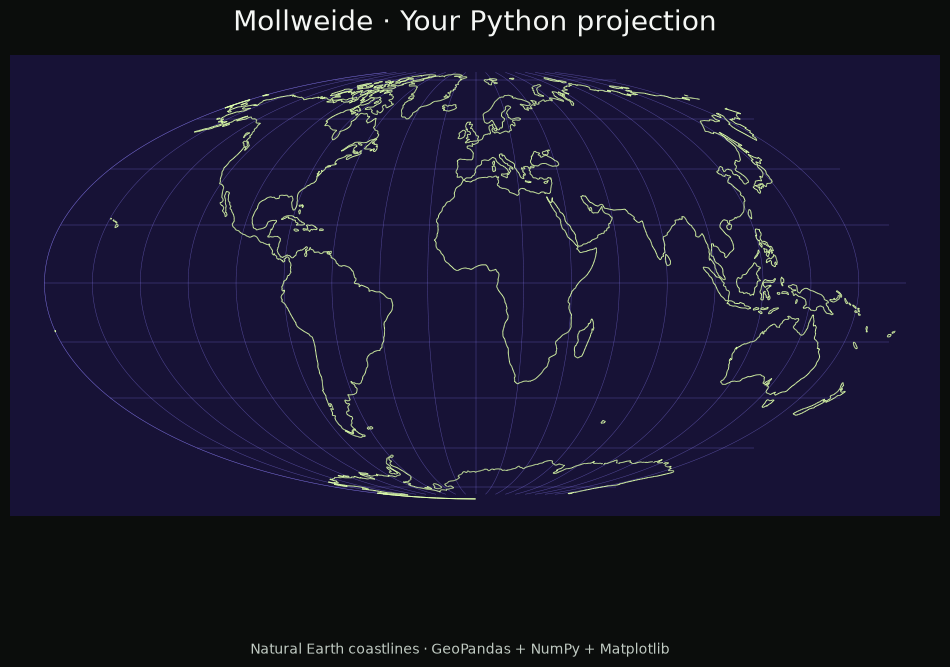

In [5]:
fig, ax = plt.subplots(figsize=(12, 8), facecolor="#0B0D0C")
ax.set_facecolor("#171236")
ax.add_collection(LineCollection(grid_lines, colors="#9183FF", linewidths=0.35, alpha=0.5))
ax.add_collection(LineCollection(coastlines, colors="#DEFFAA", linewidths=0.7))
ax.autoscale()
ax.margins(0.04)
ax.set_aspect("equal")
ax.set_title("Mollweide · Your Python projection", color="#F5F7F5", fontsize=20, pad=18)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
fig.text(0.5, 0.035, "Natural Earth coastlines · GeoPandas + NumPy + Matplotlib", ha="center", color="#C1CBC3", fontsize=10)
plt.show()

## Try a change

Edit a coefficient or operation in `project`, then rerun the drawing cells. What moved? What stayed proportional? The projection controls the tradeoffs; GeoPandas supplies the real geography.